# Sprint 13 — Previsão de rotatividade na Model Fitness

### por Luiz Trajano

---

## Contexto

Numa academia o cliente raramente cancela. Ele vem algumas vezes, vai cada vez menos e um dia some. Quando a academia percebe, ele já foi. A Model Fitness quer agir antes disso, e para isso precisa saber quem está perto de sair.

A rede me entregou os perfis de 4.000 clientes: dados de contrato, de frequência, de gastos e de perfil, junto com a informação de quem saiu no mês em questão. Com isso eu consigo comparar quem saiu com quem ficou e treinar um modelo que aprende a diferença.

**As perguntas que a análise precisa responder:**

1. Quem tem mais chance de sair no mês seguinte, e com que precisão consigo prever isso?
2. Que tipos de cliente existem na base, e quais deles saem mais?
3. O que a academia pode fazer para segurar cada tipo de cliente?

No fim entrego um modelo de previsão comparado com uma linha de base, cinco retratos de cliente com a taxa de saída de cada um e recomendações de retenção.

## Índice

- [0. Setup](#0.-Setup)
- [1. Os dados](#1.-Os-dados)
  - [1.1 Visão geral](#1.1-Visão-geral)
- [2. Análise exploratória](#2.-Análise-exploratória)
  - [2.1 Ausentes, duplicados e describe()](#2.1-Ausentes,-duplicados-e-describe())
  - [2.2 Médias de quem saiu e de quem ficou](#2.2-Médias-de-quem-saiu-e-de-quem-ficou)
  - [2.3 Distribuições por grupo](#2.3-Distribuições-por-grupo)
  - [2.4 Matriz de correlação](#2.4-Matriz-de-correlação)
- [3. Modelo de previsão do churn](#3.-Modelo-de-previsão-do-churn)
  - [3.1 X, y, divisão e linha de base](#3.1-X,-y,-divisão-e-linha-de-base)
  - [3.2 Regressão logística](#3.2-Regressão-logística)
  - [3.3 Floresta aleatória](#3.3-Floresta-aleatória)
  - [3.4 Comparação dos modelos](#3.4-Comparação-dos-modelos)
  - [3.5 O que pesa no churn](#3.5-O-que-pesa-no-churn)
- [4. Agrupamento de clientes](#4.-Agrupamento-de-clientes)
  - [4.1 Padronizar sem o Churn](#4.1-Padronizar-sem-o-Churn)
  - [4.2 Dendrograma](#4.2-Dendrograma)
  - [4.3 K-Means com 5 grupos](#4.3-K-Means-com-5-grupos)
  - [4.4 Perfil médio por grupo](#4.4-Perfil-médio-por-grupo)
  - [4.5 Distribuições por grupo](#4.5-Distribuições-por-grupo)
  - [4.6 Churn por grupo](#4.6-Churn-por-grupo)
- [5. Conclusão geral e recomendações](#5.-Conclusão-geral-e-recomendações)

---

## Descrição dos dados — arquivo `gym_churn_us.csv`

Cada linha é um cliente. `Churn` é o mês em questão; as demais colunas descrevem o mês anterior.

| coluna | descrição |
|---|---|
| `Churn` | 1 = o cliente saiu no mês em questão (alvo) |
| `gender` | gênero (0/1; o enunciado não diz qual código é qual) |
| `Near_Location` | mora ou trabalha perto da academia |
| `Partner` | funcionário de empresa parceira (tem desconto) |
| `Promo_friends` | entrou pela promoção "traga um amigo" |
| `Phone` | informou o telefone |
| `Age` | idade (o enunciado escreve `age`) |
| `Lifetime` | meses desde a primeira visita |
| `Contract_period` | duração do contrato em meses |
| `Month_to_end_contract` | meses até o contrato vencer |
| `Group_visits` | participa de aulas em grupo |
| `Avg_class_frequency_total` | média de visitas por semana em toda a vida do cliente |
| `Avg_class_frequency_current_month` | média de visitas por semana no mês corrente |
| `Avg_additional_charges_total` | total gasto em outros serviços (café, loja, massagem...) |

---

# 0. Setup

In [1]:
# =============================================================================
# SETUP — bibliotecas, estilo pessoal, constantes e caminho do arquivo
# =============================================================================
# --- 1. Bibliotecas ----------------------------------------------------------
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# --- 2. Ajustes de exibição --------------------------------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# --- 3. Meu estilo visual ----------------------------------------------------
meu_estilo = {
    'figure.figsize':   (12, 5),
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#0d0d0d',
    'savefig.facecolor':'#0d0d0d',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#aaaaaa',
    'axes.titlecolor':  '#ffffff',
    'text.color':       '#aaaaaa',
    'xtick.color':      '#aaaaaa',
    'ytick.color':      '#aaaaaa',
    'grid.color':       '#222222',
    'axes.grid':        True,
    'axes.grid.axis':   'y',
    'axes.axisbelow':   True,
    'axes.prop_cycle':  cycler(color=['#5B6BF5', '#FF6B6B', '#F5A623', '#4ECDC4', '#C77DFF']),
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#333333',
}

sns.set_theme(style='dark', rc=meu_estilo)   # seaborn primeiro, meu rc por cima
plt.rcParams.update(meu_estilo)

CORES = ['#5B6BF5', '#FF6B6B', '#F5A623', '#4ECDC4', '#C77DFF']
COR_FICOU, COR_SAIU = '#5B6BF5', '#FF6B6B'   # mesma convenção em todos os gráficos

# --- 4. Constantes -----------------------------------------------------------
RANDOM_STATE = 42   # o enunciado exige random_state na divisão e nos modelos
N_CLUSTERS = 5      # fixado pelo enunciado para comparar com outros alunos

# --- 5. Pasta das imagens e caminho do arquivo -------------------------------
# O notebook mora em notebooks/, então localmente as imagens vão para ../images.
PASTA_IMAGENS = '../images' if os.path.isdir('../images') else 'images'
os.makedirs(PASTA_IMAGENS, exist_ok=True)

# Testo os caminhos em ordem e fico com o primeiro que existe: assim o mesmo
# notebook roda local, na plataforma do projeto e no Colab sem eu trocar nada.
CAMINHOS_POSSIVEIS = [
    'data/gym_churn_us.csv',
    '../data/gym_churn_us.csv',
    '/datasets/gym_churn_us.csv',
    '/content/gym_churn_us.csv',
]
path = next((c for c in CAMINHOS_POSSIVEIS if os.path.exists(c)), None)
print('arquivo:', path, '| imagens em:', PASTA_IMAGENS)

arquivo: ../data/gym_churn_us.csv | imagens em: ../images


---

# 1. Os dados

> **Enunciado (Passo 1):** Model Fitness forneceu a você dados CSV contendo dados sobre rotatividade em
> um determinado mês e informações sobre o mês anterior. Caminho do arquivo: `/datasets/gym_churn_us.csv`.
> Baixe o conjunto de dados.

Antes de qualquer conta, abro o arquivo e confiro o que tenho na mão: formato, tipos das colunas e algumas linhas reais. Depois comparo os nomes e os valores com o que o enunciado descreve, porque qualquer diferença entre os dois muda a leitura do resto da análise.

## 1.1 Visão geral

> *Enunciado: "Baixe o conjunto de dados."*

In [2]:
# -----------------------------------------------------------------------------
# 1.1 Visão geral — o que eu tenho na mão?
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Leio o arquivo pelo `path` do SETUP e olho formato, tipos e linhas reais
# antes de qualquer conta. Uso `sample` além do `head` porque as primeiras
# linhas podem ter uma ordem que não representa a base inteira.
# Depois comparo os nomes e os valores reais com o enunciado.

# --- PARTE 1 — leitura e formato ---------------------------------------------
gym = pd.read_csv(path)

print('linhas x colunas:', gym.shape, '\n')
gym.info()

# random_state: a mesma amostra sai em toda execução, e o texto da conclusão
# continua batendo com a saída.
print('\nAmostra aleatória de 5 clientes:')
display(gym.sample(5, random_state=RANDOM_STATE))

print('Primeiras 5 linhas:')
display(gym.head())

# --- PARTE 2 — nomes e valores contra o enunciado -----------------------------
# colunas, value_counts() de Contract_period
print('\nColunas do DataFrame:')
print(gym.columns)
values_of_contract = gym['Contract_period'].value_counts().sort_index()
print('\nValores de Contract_period:')
print(values_of_contract)

linhas x colunas: (4000, 14) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
555,1,1,0,0,1,6,1,37,205.631751,5.0,2,1.400690,1.614663,0
3491,0,0,0,0,1,6,0,27,137.370917,6.0,24,0.918920,1.093414,0
527,1,1,0,0,1,1,1,25,41.607768,1.0,1,2.893104,2.813602,0
3925,1,0,0,0,1,1,0,31,9.593524,1.0,14,2.131718,2.147013,0
2989,1,1,0,0,0,1,0,30,275.271537,1.0,4,1.653789,1.738444,0


Primeiras 5 linhas:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0



Colunas do DataFrame:
Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total',
       'Avg_class_frequency_current_month', 'Churn'],
      dtype='object')

Valores de Contract_period:
Contract_period
1     2207
6      833
12     960
Name: count, dtype: int64


In [3]:
print('\nDistribuição percentual de Contract_period:')
print(gym['Contract_period'].value_counts(normalize=True).sort_index().mul(100).round(1))
print('\nMonth_to_end_contract só tem inteiros?', (gym['Month_to_end_contract'] % 1 == 0).all())


Distribuição percentual de Contract_period:
Contract_period
1     55.2
6     20.8
12    24.0
Name: proportion, dtype: float64

Month_to_end_contract só tem inteiros? True


**Conclusão 1.1 — A base está completa e toda numérica, com duas diferenças em relação ao enunciado:**

Tenho 4.000 linhas e 14 colunas, todas numéricas (10 inteiras e 4 decimais). Nenhuma coluna tem valor ausente: todas mostram 4.000 não nulos no `info()`. Duplicados e valores fora do esperado eu confiro na 2.1.

**As diferenças.** O enunciado escreve `age`, mas no arquivo a coluna é `Age`, com A maiúsculo. E o enunciado fala em contratos de 1, 3, 6 e 12 meses, mas o de 3 meses não existe nos dados: só aparecem 1, 6 e 12.

**Os contratos.** O contrato de 1 mês domina, com 2.207 clientes (55,2%). Depois vêm o de 12 meses, com 960 (24,0%), e o de 6 meses, com 833 (20,8%). Mais da metade da base pode sair no mês seguinte sem quebrar contrato, e isso deve pesar no churn (apenas suposição por agora).

**Os tipos.** `Month_to_end_contract` está como decimal, mas só tem valores inteiros. Não muda o modelo, então mantenho como está. As colunas `Avg_*` são médias de verdade e ficam decimais.

---

# 2. Análise exploratória

> **Enunciado (Passo 2):** Olhe para o conjunto de dados: ele contém alguma característica ausente? Estude
> a média de valores e desvio padrão (use o método `describe()`). Observe a média dos valores médios das
> características em dois grupos: para aqueles que ficaram (use o método `groupby()`). Faça histogramas de
> barra e distribuições de características para aqueles que saíram (rotatividade) e aqueles que ficaram.
> Construa a matriz de correlação e a exiba.

Na análise exploratória procuro três coisas antes de modelar. Primeiro, a qualidade do dado: ausentes, duplicados e valores que não fazem sentido. Depois, o que separa quem saiu de quem ficou, nas médias, nas distribuições e nas taxas de saída. Por fim, as colunas que carregam quase a mesma informação, porque elas atrapalham a leitura do modelo na seção 3.

## 2.1 Ausentes, duplicados e describe()

> *Enunciado: "Ele contém alguma característica ausente? Estude a média de valores e desvio padrão (use o método describe())."*

In [4]:
# -----------------------------------------------------------------------------
# 2.1 Ausentes, duplicados e describe()
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Confiro ausentes e duplicados antes de qualquer média.
# No describe() separo dois tipos de coluna: nas binárias (0/1) a média é a
# proporção de clientes com a característica; nas contínuas olho média,
# desvio e extremos. Também meço a proporção de Churn, que vira a linha de
# base do modelo na seção 3.

# --- PARTE 1 — ausentes e duplicados ------------------------------------------
print('\nAusentes por coluna:')
print(gym.isna().sum())
print('\nDuplicados no DataFrame:')
print(gym.duplicated().sum())

# --- PARTE 2 — describe() -----------------------------------------------------
# describe().T para ler uma coluna por linha
print('\nDescrição estatística das colunas numéricas:')
display(gym.describe().T)

# --- PARTE 3 — proporção de churn ---------------------------------------------
print('\nClientes por Churn (absoluto)')
print(gym['Churn'].value_counts())
print('\nProporção de Churn (percentual):')
print(gym['Churn'].value_counts(normalize=True).mul(100).round(1))


Ausentes por coluna:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Duplicados no DataFrame:
0

Descrição estatística das colunas numéricas:


,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000



Clientes por Churn (absoluto)
Churn
0    2939
1    1061
Name: count, dtype: int64

Proporção de Churn (percentual):
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


In [5]:
# -----------------------------------------------------------------------------
# 2.1b Checagem dos implícitos
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Zero ausente no info() não garante dado coerente. Confiro as regras que o
# dado tem de obedecer antes de confiar nas médias.

# --- PARTE 1 — binárias só com 0 e 1 -----------------------------------------
print(gym.nunique())
print('\nColunas com exatamente 2 valores')
binary_columns = [col for col in gym.columns if gym[col].nunique() == 2]
print(binary_columns)

# Dois valores não garantem que sejam 0 e 1; confiro o mínimo e o máximo.
print('\nMínimo e máximo das colunas binárias:')
print(gym[binary_columns].agg(['min', 'max']))

# --- PARTE 2 — meses restantes nunca acima do contrato -----------------------
# Somo a série True/False: cada True conta 1, então sai o número de clientes.
excede_contrato = gym['Month_to_end_contract'] > gym['Contract_period']
print('\nClientes com meses restantes acima do contrato:', excede_contrato.sum())

# --- PARTE 3 — duplicados ignorando o Churn ----------------------------------
# (o mesmo cliente com rótulos diferentes seria contradição)
print('\nDuplicados ignorando o Churn:', gym.drop(columns='Churn').duplicated().sum())

gender                                  2
Near_Location                           2
Partner                                 2
Promo_friends                           2
Phone                                   2
Contract_period                         3
Group_visits                            2
Age                                    23
Avg_additional_charges_total         4000
Month_to_end_contract                  12
Lifetime                               29
Avg_class_frequency_total            3913
Avg_class_frequency_current_month    3820
Churn                                   2
dtype: int64

Colunas com exatamente 2 valores
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits', 'Churn']

Mínimo e máximo das colunas binárias:
     gender  Near_Location  Partner  Promo_friends  Phone  Group_visits  Churn
min       0              0        0              0      0             0      0
max       1              1        1              1      1             1      1

In [6]:
# --- PARTE 4 — quantos zeros em Lifetime e nas duas frequências --------------
# Mostro absoluto e percentual juntos, que é como os números vão para a conclusão.
colunas_zero = ['Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
zeros = (gym[colunas_zero] == 0).sum()
print('\nClientes com valor zero (absoluto e % da base):')
print(pd.DataFrame({'clientes': zeros, '% da base': (zeros / len(gym) * 100).round(1)}))

# --- PARTE 5 — os zeros de frequência contra o churn -------------------------
# Separo quem nunca vai de quem parou só no mês corrente. Se quem parou no mês
# quase sempre sai, a frequência do mês pode estar medindo a própria saída.
zero_total = gym['Avg_class_frequency_total'] == 0
zero_mes = gym['Avg_class_frequency_current_month'] == 0

# np.select testa na ordem: primeiro "nunca vai", depois "parou no mês".
grupo_frequencia = np.select(
    [zero_total, zero_mes],
    ['nunca vai', 'parou no mês'],
    default='frequenta'
)

# A média de Churn dentro de cada grupo é a taxa de churn do grupo.
churn_por_frequencia = (
    gym.groupby(grupo_frequencia)['Churn']
       .agg(clientes='size', sairam='sum', taxa_churn='mean')
)
churn_por_frequencia['taxa_churn'] = (churn_por_frequencia['taxa_churn'] * 100).round(1)
print('\nChurn por padrão de frequência (taxa em %):')
print(churn_por_frequencia)

# Se a média total inclui o mês corrente, total 0 com mês > 0 é contradição.
print('\nFrequência total 0, mas frequência do mês > 0:', (zero_total & ~zero_mes).sum())


Clientes com valor zero (absoluto e % da base):
                                   clientes  % da base
Lifetime                                487       12.2
Avg_class_frequency_total                88        2.2
Avg_class_frequency_current_month       181        4.5

Churn por padrão de frequência (taxa em %):
              clientes  sairam  taxa_churn
frequenta         3790     925        24.4
nunca vai           88      20        22.7
parou no mês       122     116        95.1

Frequência total 0, mas frequência do mês > 0: 29


**Conclusão 2.1 — O dado está limpo, um em cada quatro clientes saiu, e parar de ir no mês quase sempre termina em saída:**

**A qualidade.** Não há ausentes nem duplicados, nem mesmo quando ignoro o `Churn`, então nenhum cliente aparece repetido com rótulos diferentes. As 7 colunas binárias só têm 0 e 1, e os meses restantes nunca passam do contrato. As idades vão de 18 a 41 anos, com mediana de 29 e metade dos clientes entre 27 e 31, uma faixa plausível para academia. A falta de clientes acima de 41 pode indicar uma base recortada antes de chegar a mim (hipótese) ou apenas um padrão que a academia acabou criando.

**Os tipos de coluna.** Nas binárias, a média é a fração de clientes com valor 1. Os 84,5% de `Near_Location` mostram uma base que mora ou trabalha perto, o que sugere academias de bairro (hipótese), e os 90,4% de `Phone` mostram que quase todos deixaram contato. As contínuas têm cauda longa: `Lifetime` tem mediana de 3 meses e máximo de 31, e `Avg_additional_charges_total` tem mediana de 136 e máximo de 552. Em `Contract_period` a média de 4,7 não descreve ninguém, porque a coluna só tem 1, 6 e 12 meses, e a mediana é 1.

**Os zeros.** 487 clientes (12,2%) têm `Lifetime` 0 e são clientes novos, não erro. 88 (2,2%) têm frequência total 0 e saem a uma taxa de 22,7%, perto dos 24,4% de quem frequenta. O grupo que chama a atenção é outro: 122 clientes frequentavam e não foram nenhuma vez no mês corrente, e 116 deles saíram (95,1%). Uma coluna que separa o churn assim provavelmente mede o próprio mês da saída, então na seção 3 testo o modelo sem `Avg_class_frequency_current_month`. Também há 29 clientes com frequência total 0 e frequência do mês maior que 0, o que só é contradição se a média total incluir o mês corrente, e o enunciado não define isso.

**O churn.** 1.061 clientes saíram (26,5%) e 2.939 ficaram (73,5%). Um modelo que chuta "ninguém sai" já acerta 73,5%, e essa é a linha de base que os modelos da seção 3 precisam superar.

## 2.2 Médias de quem saiu e de quem ficou

> *Enunciado: "Observe a média dos valores médios das características em dois grupos: para aqueles que ficaram (use o método groupby())."*

In [7]:
# -----------------------------------------------------------------------------
# 2.2 Médias por grupo (groupby Churn)
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Agrupo por Churn e comparo as médias lado a lado.
# Calculo também a diferença relativa entre os grupos, para ordenar as
# características pelo tamanho da separação e não pela ordem das colunas.
# Guardo o resultado numa variável nova, sem sobrescrever o DataFrame.

# --- PARTE 1 — médias por grupo -----------------------------------------------
gym_means = gym.groupby('Churn').mean().T

# --- PARTE 2 — diferença absoluta e relativa ----------------------------------
# ordeno pelo tamanho da diferença, mantendo o sinal
gym_means['diff_abs'] = (gym_means[1] - gym_means[0])
gym_means['diff_rel'] = (gym_means['diff_abs'] / gym_means[0]) * 100
gym_means['diff_rel'] = gym_means['diff_rel'].round(1)
gym_means = gym_means.sort_values('diff_rel', key=lambda x: x.abs(), ascending=False)
print('\nMédias por grupo com diferenças absoluta e relativa:')
display(gym_means.round(2))


Médias por grupo com diferenças absoluta e relativa:


Churn,0,1,diff_abs,diff_rel
Lifetime,4.71,0.99,-3.72,-79.0
Contract_period,5.75,1.73,-4.02,-69.9
Month_to_end_contract,5.28,1.66,-3.62,-68.5
Avg_class_frequency_current_month,2.03,1.04,-0.98,-48.5
Promo_friends,0.35,0.18,-0.17,-48.0
Group_visits,0.46,0.27,-0.20,-42.1
Partner,0.53,0.36,-0.18,-33.5
Avg_additional_charges_total,158.45,115.08,-43.36,-27.4
Avg_class_frequency_total,2.02,1.47,-0.55,-27.2
Near_Location,0.87,0.77,-0.10,-12.0


**Conclusão 2.2 — Quem sai é cliente novo, de contrato curto, que frequenta menos e tem menos laços com a academia:**

**Tempo e contrato.** A maior diferença está no tempo de casa: quem saiu tinha em média 0,99 mês de academia, contra 4,71 de quem ficou, 79,0% abaixo. O contrato segue o mesmo desenho, com 1,73 mês contra 5,75 (69,9% abaixo), e os meses restantes também, com 1,66 contra 5,28 (68,5% abaixo). Contrato e meses restantes andam juntos e contam quase a mesma história, o que confiro na matriz de correlação da 2.4.

**Frequência.** Quem saiu foi em média 1,04 vez por semana no mês corrente, contra 2,03 de quem ficou, 48,5% abaixo. Na frequência total a distância é menor, com 1,47 contra 2,02 (27,2% abaixo). Quem sai já ia menos e caiu ainda mais no último mês, o mesmo sinal que vi nos 122 clientes que pararam de ir (seção 2.1).

**Laços sociais.** Nas binárias a média é a fração de clientes. Vieram por indicação de amigo 18% de quem saiu, contra 35% de quem ficou (48,0% abaixo). Fazem aula em grupo 27% contra 46% (42,1% abaixo), e são de empresa parceira 36% contra 53% (33,5% abaixo). Esses vínculos aparecem mais entre quem ficou, mas a tabela não mostra que são eles que seguram o cliente: quem já tende a ficar pode ser quem procura aula em grupo (hipótese).

**Diferenças menores, mas não desprezíveis.** Quem saiu gasta menos com serviços extras, 115,08 contra 158,45 (27,4% abaixo), o que não é uma diferença pequena. Também é mais novo, 26,99 anos contra 29,98 (10,0% abaixo), e mora ou trabalha perto com menos frequência: `Near_Location` cai de 87% para 77% (12,0% abaixo). Só `gender` e `Phone` ficam praticamente iguais nos dois grupos, então a codificação desconhecida do `gender` não atrapalha a leitura.

**Um cuidado com este ranking.** A diferença percentual depende da escala e da dispersão de cada coluna. Na idade, que varia pouco (metade dos clientes entre 27 e 31 anos), uma diferença de 10% separa mais os grupos do que parece. Trato esta ordem como uma primeira leitura, não como medida de importância: a correlação da 2.4 e os modelos da seção 3 refinam essa leitura.

## 2.3 Distribuições por grupo

> *Enunciado: "Faça histogramas de barra e distribuições de características para aqueles que saíram (rotatividade) e aqueles que ficaram."*

In [8]:
# -----------------------------------------------------------------------------
# 2.3 Distribuições por grupo — saiu x ficou
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Contínuas: histograma com densidade, saiu e ficou sobrepostos, porque os
# grupos têm tamanhos diferentes e a contagem bruta engana.
# Binárias: barra com a taxa de churn em cada valor (0 e 1).
# Ficou = azul, saiu = vermelho. savefig antes do show.

# --- PARTE 1 — listas de colunas contínuas e binárias -------------------------
# Barras: as binárias sem o Churn (é o alvo) e Contract_period, que só tem
# 3 valores e num histograma viraria 3 barras soltas.
columns_bar = [col for col in binary_columns if col != 'Churn'] + ['Contract_period']

# Histograma: o resto. Pego só os nomes (.columns), não os dados.
continuous_columns = gym.drop(columns=binary_columns + ['Contract_period']).columns.tolist()

print('Barras:', columns_bar)
print('Histograma:', continuous_columns)

Barras: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits', 'Contract_period']
Histograma: ['Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']


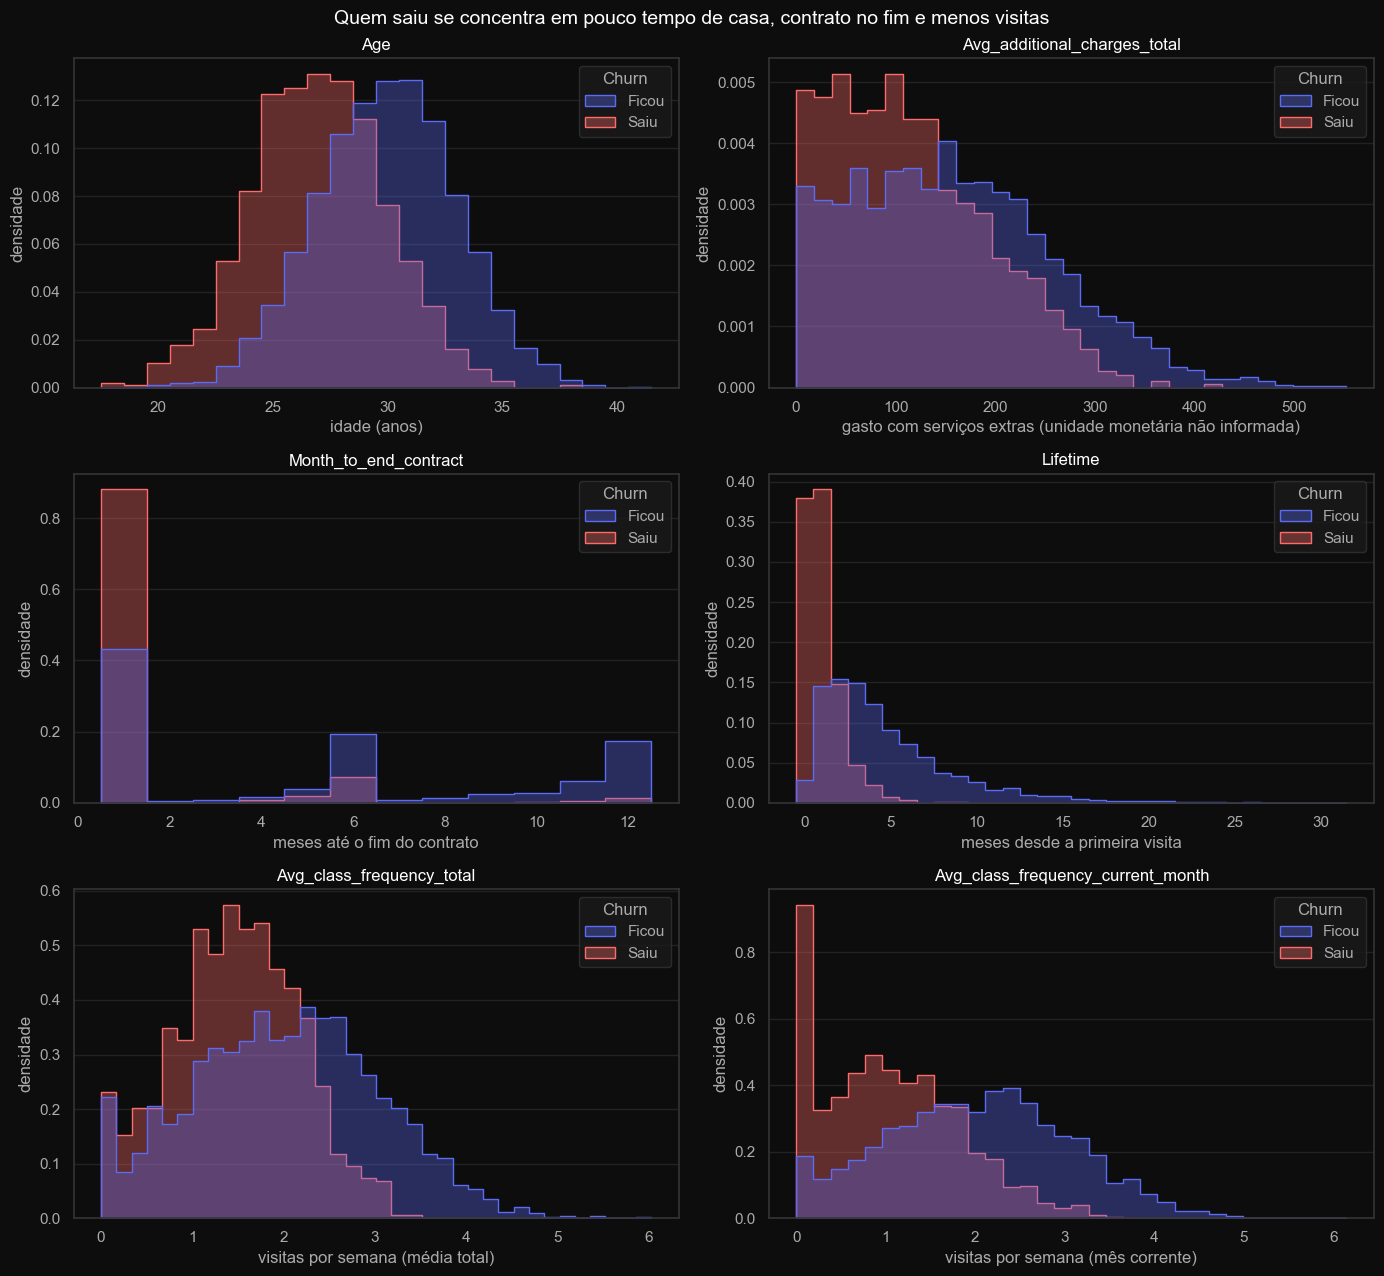

In [9]:
# --- PARTE 2 — histogramas das contínuas --------------------------------------
# Densidade com common_norm=False: cada grupo soma 1 sozinho, então comparo o
# formato das distribuições, não o tamanho dos grupos (2.939 x 1.061).
# Colunas só com inteiros ganham discrete=True (uma barra por valor).
COR_GRUPO = {'Ficou': '#5B6BF5', 'Saiu': '#FF6B6B'}
grupo = gym['Churn'].map({0: 'Ficou', 1: 'Saiu'})   # rótulo para a legenda, sem mexer no gym

# Unidade de cada coluna para o eixo x (o título já mostra o nome).
# Importante pra leitura melhor e interpretação dos gráficos
UNIDADE = {
    'Age': 'idade (anos)',
    'Avg_additional_charges_total': 'gasto com serviços extras (unidade monetária não informada)',
    'Month_to_end_contract': 'meses até o fim do contrato',
    'Lifetime': 'meses desde a primeira visita',
    'Avg_class_frequency_total': 'visitas por semana (média total)',
    'Avg_class_frequency_current_month': 'visitas por semana (mês corrente)',
}

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for ax, col in zip(axes.flat, continuous_columns):
    discreta = (gym[col] % 1 == 0).all()
    sns.histplot(
        data=gym, x=col, hue=grupo, hue_order=['Ficou', 'Saiu'], palette=COR_GRUPO,
        stat='density', common_norm=False, discrete=discreta,
        element='step', alpha=0.35, ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel(UNIDADE[col])
    ax.set_ylabel('densidade')
fig.suptitle('Quem saiu se concentra em pouco tempo de casa, contrato no fim e menos visitas',
            fontsize=14, color='#ffffff')
fig.tight_layout()
plt.savefig(f'{PASTA_IMAGENS}/2_3_histogramas_continuas.png')
plt.show()

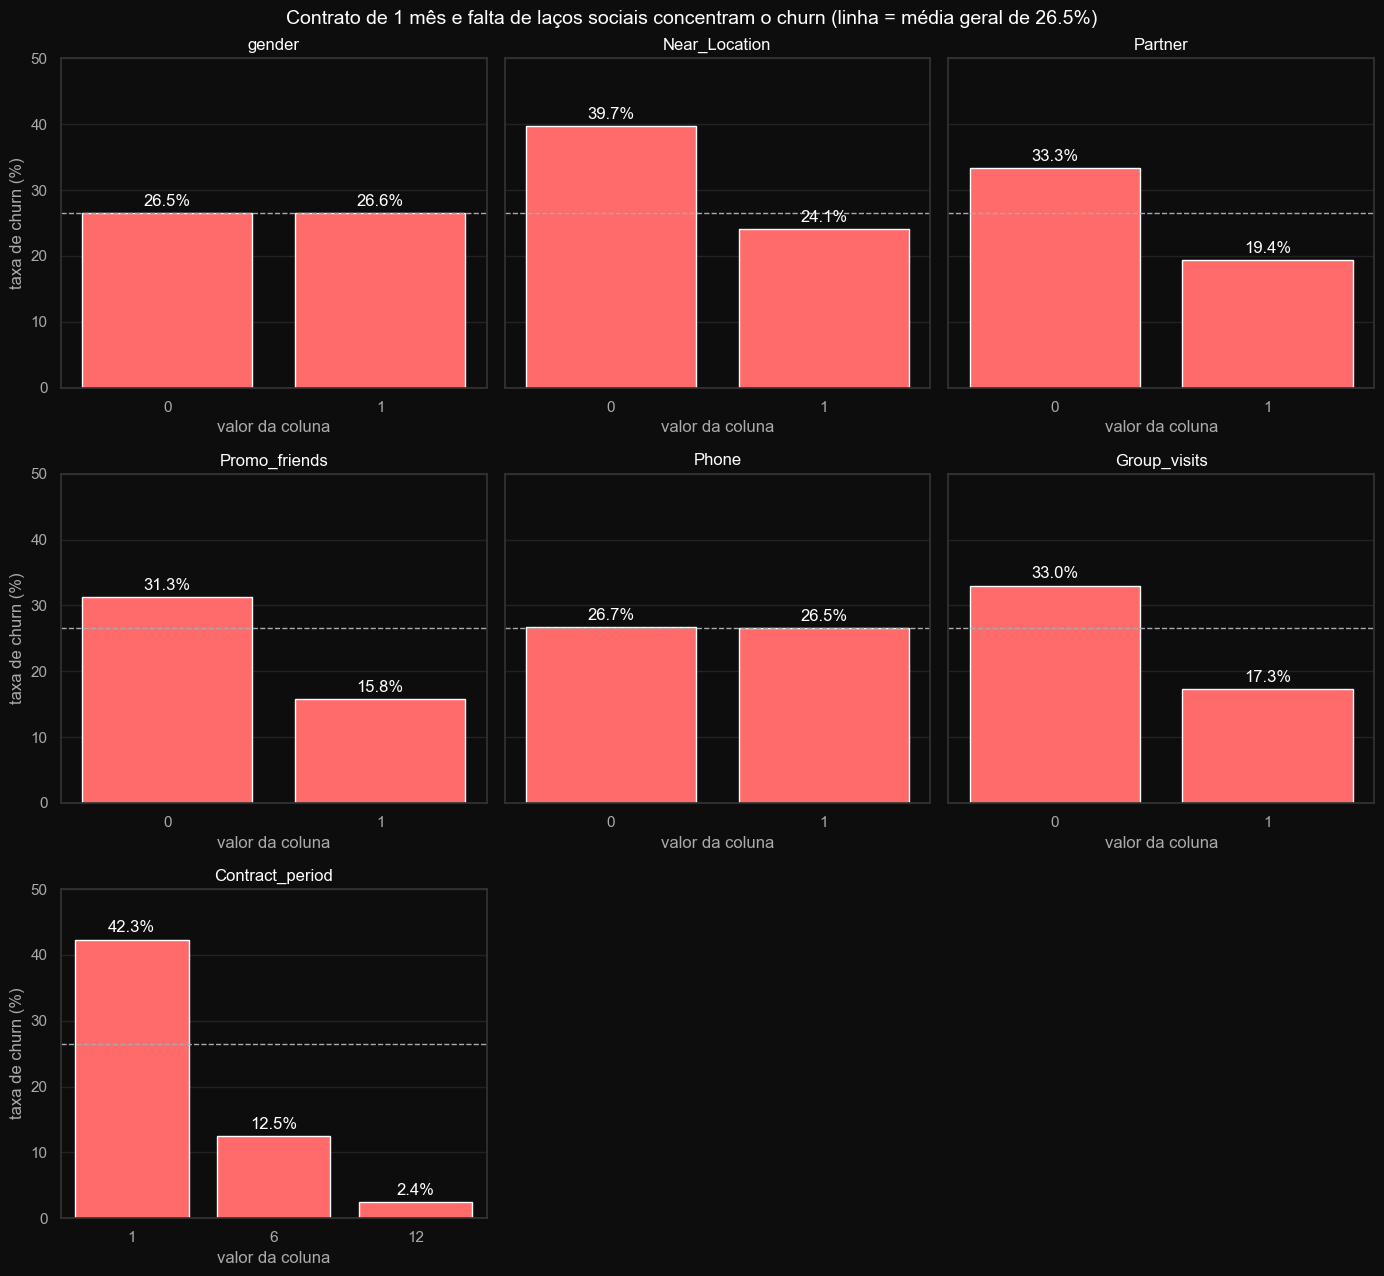

In [10]:
# --- PARTE 3 — barras das binárias --------------------------------------------
# Taxa de churn em cada valor da coluna. A linha tracejada é a taxa geral:
# barra acima dela = grupo que sai mais que a média.
TAXA_CHURN_GERAL = gym['Churn'].mean() * 100

fig, axes = plt.subplots(3, 3, figsize=(14, 13), sharey=True)
for ax, col in zip(axes.flat, columns_bar):
    taxa = (gym.groupby(col)['Churn'].mean() * 100).reset_index()
    sns.barplot(data=taxa, x=col, y='Churn', order=taxa[col].tolist(),
                color='#FF6B6B', saturation=1, ax=ax)
    ax.bar_label(ax.containers[0], fmt='%.1f%%', color='#ffffff', padding=3)
    ax.axhline(TAXA_CHURN_GERAL, color='#aaaaaa', linestyle='--', linewidth=1)
    ax.set_title(col)
    ax.set_xlabel('valor da coluna')
    ax.set_ylabel('taxa de churn (%)')

axes.flat[0].set_ylim(0, 50)   # eixo compartilhado; folga para o rótulo de 42,3%
for ax in axes.flat[len(columns_bar):]:
    ax.axis('off')             # 7 gráficos em 9 espaços: escondo os que sobram

fig.suptitle(f'Contrato de 1 mês e falta de laços sociais concentram o churn '
            f'(linha = média geral de {TAXA_CHURN_GERAL:.1f}%)',
            fontsize=14, color='#ffffff')
fig.tight_layout()
plt.savefig(f'{PASTA_IMAGENS}/2_3_taxa_churn_barras.png')
plt.show()

**Conclusão 2.3 — O tempo de casa, o contrato e a frequência do mês separam bem quem sai; gênero e telefone não separam nada:**

**Onde as distribuições se separam.** Em `Lifetime` quem saiu se concentra entre 0 e 2 meses de casa, enquanto quem ficou se espalha até 30. Em `Month_to_end_contract` quase todo cliente que saiu estava a 1 mês do fim do contrato, e quem ficou tem picos em 6 e 12 meses. Na frequência do mês corrente, quem saiu tem um pico em zero visitas que não aparece em quem ficou. Esse pico é o grupo dos 122 clientes que pararam de ir (seção 2.1), que a média da 2.2 escondia.

**Nas barras.** A taxa de churn cai com o tamanho do contrato: 42,3% no contrato de 1 mês, 12,5% no de 6 e 2,4% no de 12. Os laços sociais seguem o mesmo sentido: sem indicação de amigo a taxa é 31,3%, contra 15,8% com indicação; sem aula em grupo é 33,0%, contra 17,3%; e sem empresa parceira é 33,3%, contra 19,4%. Quem não mora nem trabalha perto sai a 39,7%, contra 24,1% de quem está perto.

**Onde se sobrepõem.** Idade, frequência total e gasto com serviços extras estão deslocados na direção esperada (quem saiu é mais novo, vai menos e gasta menos), mas as curvas se cobrem em boa parte, então cada uma sozinha separa pouco. `gender` e `Phone` não separam nada: as taxas ficam em 26,5% e 26,6% e em 26,7% e 26,5%, em cima da média geral de 26,5%.

**O que levo para o modelo.** As características que mais separam são justamente as suspeitas: contrato e meses restantes contam quase a mesma história, e a frequência do mês pode estar medindo a própria saída. Confiro a primeira na correlação da 2.4 e testo a segunda na seção 3.

## 2.4 Matriz de correlação

> *Enunciado: "Construa a matriz de correlação e a exiba."*

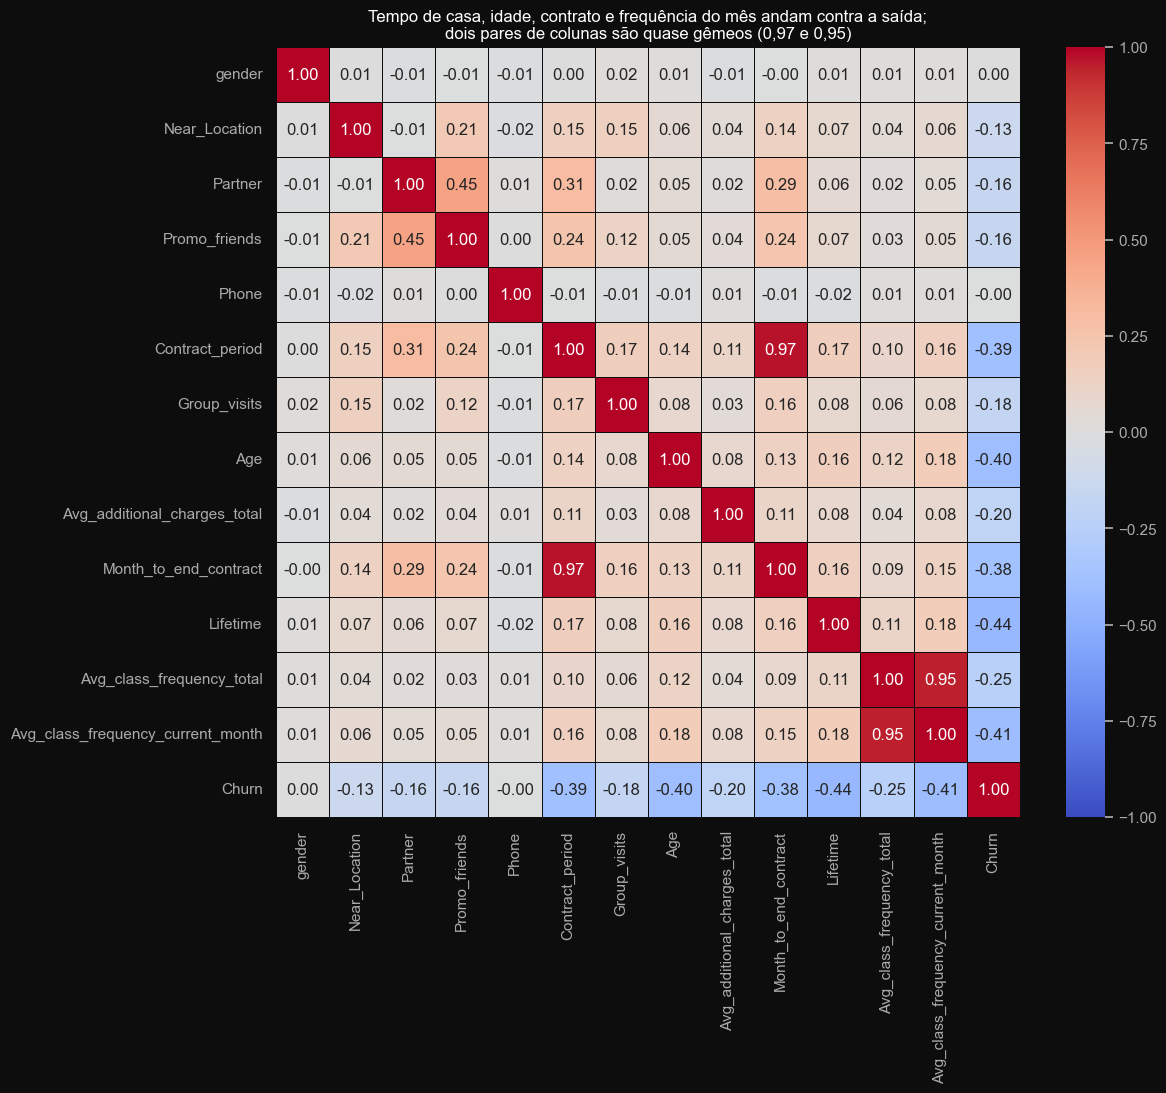

In [11]:
# -----------------------------------------------------------------------------
# 2.4 Matriz de correlação
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Heatmap anotado da correlação de todas as colunas, Churn incluído.
# Procuro duas coisas: a correlação de cada característica com Churn e os
# pares quase gêmeos entre as características. Par gêmeo deixa os
# coeficientes da regressão logística instáveis (o sinal pode inverter).

# --- PARTE 1 — matriz e heatmap -----------------------------------------------
# Escala fixa de -1 a +1 e centro em 0: a cor diz o sinal e a força sem
# depender dos valores que aparecerem. Vermelho = sobem juntas; azul = uma sobe,
# a outra desce.
matriz_corr = gym.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor='#0d0d0d')
plt.title('Tempo de casa, idade, contrato e frequência do mês andam contra a saída;\n'
        'dois pares de colunas são quase gêmeos (0,97 e 0,95)')
plt.savefig(f'{PASTA_IMAGENS}/2_4_matriz_correlacao.png')
plt.show()


In [12]:
# --- PARTE 2 — correlação com Churn ordenada ----------------------------------
# Pego só a coluna Churn (1 = saiu, 0 = ficou), tiro a linha dela mesma (r = 1)
# e ordeno pelo tamanho mantendo o sinal. Negativo = quanto maior a
# característica, menor a proporção de clientes que saíram.
corr_churn = (
    matriz_corr['Churn']
    .drop('Churn')
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .round(2)
)
print('Correlação de cada característica com Churn (1 = saiu, 0 = ficou):')
print(corr_churn)

# --- PARTE 3 — pares acima de um limiar declarado -----------------------------
# Declaro o limiar antes de olhar os pares. Acima de 0,8, duas colunas carregam
# quase a mesma informação. Uso só o triângulo de cima para não listar cada par
# duas vezes (A×B e B×A) nem a diagonal (A×A = 1).
LIMIAR_GEMEAS = 0.8

caracteristicas = matriz_corr.drop(index='Churn', columns='Churn')
# vou agregar o numpy para criar a máscara do triângulo superior:
# (não tinha usado antes ainda) - np.triu()
# np.triu(..., k=1) cria uma máscara True só acima da diagonal;
# o .where() mantém essas células e troca o resto por NaN (o stack descarta NaN).
triangulo = caracteristicas.where(np.triu(np.ones(caracteristicas.shape, dtype=bool), k=1))
pares = triangulo.stack()   # vira uma lista de pares (coluna A, coluna B) -> r
pares_gemeos = pares[pares.abs() > LIMIAR_GEMEAS].sort_values(ascending=False).round(2)

print(f'\nPares de características com |r| > {LIMIAR_GEMEAS}:')
print(pares_gemeos)
print(f'\nVeredito: {len(pares_gemeos)} par(es) quase gêmeo(s) acima do limiar de {LIMIAR_GEMEAS}.')

Correlação de cada característica com Churn (1 = saiu, 0 = ficou):
Lifetime                            -0.44
Avg_class_frequency_current_month   -0.41
Age                                 -0.40
Contract_period                     -0.39
Month_to_end_contract               -0.38
Avg_class_frequency_total           -0.25
Avg_additional_charges_total        -0.20
Group_visits                        -0.18
Promo_friends                       -0.16
Partner                             -0.16
Near_Location                       -0.13
Phone                               -0.00
gender                               0.00
Name: Churn, dtype: float64

Pares de características com |r| > 0.8:
Contract_period            Month_to_end_contract                0.97
Avg_class_frequency_total  Avg_class_frequency_current_month    0.95
dtype: float64

Veredito: 2 par(es) quase gêmeo(s) acima do limiar de 0.8.


**Conclusão 2.4 — Todas as características que pesam têm sinal negativo, e dois pares de colunas são quase gêmeos:**

**A correlação com a saída.** Todas as correlações com o `Churn` são negativas ou zero: quanto maior a característica, menor a proporção de clientes que saíram. As mais fortes são o tempo de casa (−0,44), a frequência no mês corrente (−0,41), a idade (−0,40), o período do contrato (−0,39) e os meses restantes (−0,38). Os laços sociais vêm bem atrás, entre −0,13 e −0,18, e `gender` e `Phone` ficam em zero, o que confirma o que as barras da 2.3 mostraram. Correlação mostra que as colunas andam juntas, não que uma causa a outra.

**Revisei a leitura da idade.** Na 2.2 tratei a idade como um fator menor, porque quem saiu era em média só 3 anos mais novo (26,99 contra 29,98, 10,0% abaixo). A correlação de −0,40 mostra que eu subestimei: a idade fica entre as cinco mais fortes, ao lado do tempo de casa e do contrato. A média escondia isso porque a base é estreita, com metade dos clientes entre 27 e 31 anos, e dentro dessa faixa 3 anos separam bastante. O histograma da 2.3 já mostrava as curvas de quem saiu e de quem ficou deslocadas. Levo a idade para o modelo como característica relevante, não secundária.

**Os pares gêmeos.** Com o limiar de 0,8 que declarei antes, apareceram dois pares. `Contract_period` e `Month_to_end_contract` têm r = 0,97 e quase a mesma correlação com a saída (−0,39 e −0,38), então são a mesma informação duas vezes. As duas frequências têm r = 0,95, mas a do mês corrente se liga muito mais à saída (−0,41) do que a total (−0,25). A diferença entre elas é a queda no último mês, o mesmo sinal dos 122 clientes que pararam de ir e quase todos saíram (seção 2.1).

**O que isso faz com o modelo.** Na regressão logística, cada par gêmeo divide o peso entre as duas colunas de forma instável, e o sinal de uma delas pode até inverter. Por isso leio os coeficientes desses pares com cuidado na seção 3.5. A floresta aleatória não quebra com colunas gêmeas, mas divide a importância entre elas, e cada uma parece menos importante do que o par é de verdade.

---

# 3. Modelo de previsão do churn

> **Enunciado (Passo 3):** Construa um modelo de classificação binária para clientes onde a variável
> objetivo é a saída de usuários do próximo mês. Divida os dados de treinamento e validação em dois conjuntos
> usando a função `train_test_split()`. Treine o modelo no conjunto com dois métodos: regressão logística e
> floresta aleatória. Avalie acurácia, precisão e sensibilidade para ambos os modelos usando dados de
> validação. Use-os para comparar os modelos. Qual modelo rendeu melhores resultados? Lembre-se de indicar o
> parâmetro `random_state` quando dividir os dados e definir o algoritmo.

Só 26,5% dos clientes saíram, então um modelo que chuta "ninguém sai" já acerta 73,5% sem prever nada. Por isso a acurácia sozinha engana, e olho também a precisão (dos clientes que o modelo apontou como saída, quantos saíram de fato) e a sensibilidade (dos clientes que saíram, quantos o modelo encontrou).

Para a academia, o erro mais caro é deixar passar quem vai sair: perde a mensalidade e o cliente. Apontar como saída alguém que ia ficar custa uma ação de retenção desnecessária, como um desconto ou uma ligação. Por isso dou mais peso à sensibilidade (hipótese de custo; o enunciado não informa os valores).

## 3.1 X, y, divisão e linha de base

> *Enunciado: "Divida os dados de treinamento e validação em dois conjuntos usando a função train_test_split()."*

In [13]:
# -----------------------------------------------------------------------------
# 3.1 X, y, divisão e linha de base
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Separo X (características) de y (Churn) e divido 80/20 com
# random_state e stratify=y, para o churn ter a mesma proporção nos dois
# conjuntos. Antes de treinar qualquer modelo, calculo a acurácia do
# chute "ninguém sai": é a régua que os modelos precisam superar.

# --- PARTE 1 — X e y ----------------------------------------------------------
X = gym.drop(columns='Churn')
y = gym['Churn']
print(X.shape)
print(y.shape)

# --- PARTE 2 — train_test_split -----------------------------------------------
# stratify=y: a mesma % de clientes que saíram nos dois pedaços.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Clientes no treino: {len(X_train)} | na validação: {len(X_test)}')

# --- PARTE 3 — conferir a proporção de churn em treino e validação ------------
print('\nPorcentagem de clientes que saíram no treino: ', (y_train.mean() * 100).round(1))
print('Porcentagem de clientes que saíram na validação: ', (y_test.mean() * 100).round(1))

# --- PARTE 4 — linha de base "ninguém sai" ------------------------------------
# Simulo o chute mais simples: prever 0 (ficou) para todo cliente da
# validação. Ele acerta todos os que ficaram e não encontra nenhum que saiu.
# Guardo a acurácia numa constante para comparar com os modelos na 3.4.
previsao_ninguem_sai = np.zeros(len(y_test), dtype=int)

LINHA_DE_BASE = accuracy_score(y_test, previsao_ninguem_sai)
sensibilidade_base = recall_score(y_test, previsao_ninguem_sai)

print(f'\nAcurácia do chute "ninguém sai" na validação: {LINHA_DE_BASE:.1%}')
print(f'Clientes que saíram e o chute encontrou (sensibilidade): {sensibilidade_base:.1%}')

(4000, 13)
(4000,)
Clientes no treino: 3200 | na validação: 800

Porcentagem de clientes que saíram no treino:  26.5
Porcentagem de clientes que saíram na validação:  26.5

Acurácia do chute "ninguém sai" na validação: 73.5%
Clientes que saíram e o chute encontrou (sensibilidade): 0.0%


**Conclusão 3.1 — Dividi a base mantendo a proporção de quem saiu, e qualquer modelo precisa superar os 73,5% do chute "ninguém sai":**

**A divisão.** Separei as 13 características do cliente (X) da resposta, o `Churn` (y, com 1 para quem saiu e 0 para quem ficou), e dividi a base em 3.200 clientes para treino e 800 para validação. O `Churn` fica fora do X porque, se ficasse, o modelo veria a resposta junto com as perguntas.

**Por que estratifiquei.** Com `stratify=y` o sorteio é feito separado entre quem saiu e quem ficou, e cada pedaço recebe a mesma proporção de cada grupo. Por isso a porcentagem de clientes que saíram é 26,5% no treino, 26,5% na validação e 26,5% na base inteira (seção 2.1). Sem estratificar, o acaso poderia deixar a validação com mais ou menos saídas que a base, e as métricas dos modelos mudariam por sorte, não por mérito. Fixei o `random_state` para a divisão sair igual em toda execução.

**A linha de base.** Um chute que prevê "ficou" para todo cliente acerta 73,5% da validação, porque acerta exatamente quem ficou. Mas ele encontra 0,0% dos clientes que saíram, então não serve para nada. Isso mostra por que a acurácia sozinha engana com saídas raras: quanto menor a porcentagem de quem sai, mais alta fica a acurácia de não prever nada. Na 3.4 um modelo só vale a pena se passar dos 73,5% de acurácia e, principalmente, se encontrar uma boa parte dos clientes que saíram.

## 3.2 Regressão logística

> *Enunciado: "Treine o modelo no conjunto com dois métodos: (primeiro) regressão logística"*

In [14]:
# -----------------------------------------------------------------------------
# 3.2 Regressão logística
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Padronizo com StandardScaler: fit só no treino, transform no treino e na
# validação, para a validação não vazar para o modelo. A logística precisa
# disso para convergir e para os coeficientes serem comparáveis.
# Treino com random_state, meço na validação e guardo as métricas em
# variáveis com sufixo _logistico para a tabela da 3.4.

# --- PARTE 1 — padronização (fit só no treino) --------------------------------
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)
X_test_st = scaler.transform(X_test)

# --- PARTE 2 — treino ---------------------------------------------------------
modelo_logistico = LogisticRegression(random_state=RANDOM_STATE)
modelo_logistico.fit(X_train_st, y_train)

# --- PARTE 3 — previsões na validação -----------------------------------------
# predict corta a probabilidade em 0,5; predict_proba guarda a probabilidade de
# sair (coluna 1 = Churn 1), que o ROC-AUC precisa.
y_pred_logistico = modelo_logistico.predict(X_test_st)
y_pred_proba_logistico = modelo_logistico.predict_proba(X_test_st)[:, 1]

# --- PARTE 4 — métricas na validação ------------------------------------------
# As três primeiras são as do enunciado; F1 e ROC-AUC servem de desempate.
# O ROC-AUC recebe a probabilidade, não a classe prevista.
acuracia_logistico = accuracy_score(y_test, y_pred_logistico)
sensibilidade_logistico = recall_score(y_test, y_pred_logistico)
precisao_logistico = precision_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)
roc_auc_logistico = roc_auc_score(y_test, y_pred_proba_logistico)

print(f'\nAcurácia da regressão logística na validação: {acuracia_logistico:.1%} '
    f'(linha de base: {LINHA_DE_BASE:.1%})')
print(f'Clientes que saíram e o modelo encontrou (sensibilidade): {sensibilidade_logistico:.1%}')
print(f'Dos apontados como saída, quantos saíram de fato (precisão): {precisao_logistico:.1%}')
print(f'F1 (equilíbrio entre precisão e sensibilidade): {f1_logistico:.1%}')
print(f'ROC-AUC (0,5 = sorteio, 1 = ordenação perfeita): {roc_auc_logistico:.3f}')


Acurácia da regressão logística na validação: 92.5% (linha de base: 73.5%)
Clientes que saíram e o modelo encontrou (sensibilidade): 83.0%
Dos apontados como saída, quantos saíram de fato (precisão): 88.0%
F1 (equilíbrio entre precisão e sensibilidade): 85.4%
ROC-AUC (0,5 = sorteio, 1 = ordenação perfeita): 0.977


## 3.3 Floresta aleatória

> *Enunciado: "Treine o modelo no conjunto com dois métodos: floresta aleatória"*

In [15]:
# -----------------------------------------------------------------------------
# 3.3 Floresta aleatória
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Mesmo split da 3.1, sem padronizar: a árvore decide por cortes em cada
# coluna e não muda com a escala, então uso X_train e X_test originais.
# Defino random_state no modelo, meço na validação e guardo as métricas com
# sufixo _floresta para a tabela da 3.4.

# --- PARTE 1 — treino ---------------------------------------------------------
modelo_floresta = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
modelo_floresta.fit(X_train, y_train)

# --- PARTE 2 — previsões na validação -----------------------------------------
# predict corta em 0,5; predict_proba guarda a probabilidade de sair
# (coluna 1 = Churn 1), que o ROC-AUC precisa.
y_pred_floresta = modelo_floresta.predict(X_test)
y_pred_proba_floresta = modelo_floresta.predict_proba(X_test)[:, 1]

# --- PARTE 3 — métricas na validação ------------------------------------------
# Mesmas métricas e mesma ordem da 3.2, para a comparação ser direta.
acuracia_floresta = accuracy_score(y_test, y_pred_floresta)
sensibilidade_floresta = recall_score(y_test, y_pred_floresta)
precisao_floresta = precision_score(y_test, y_pred_floresta)
f1_floresta = f1_score(y_test, y_pred_floresta)
roc_auc_floresta = roc_auc_score(y_test, y_pred_proba_floresta)

print(f'\nAcurácia da floresta aleatória na validação: {acuracia_floresta:.1%} '
    f'(linha de base: {LINHA_DE_BASE:.1%})')
print(f'Clientes que saíram e o modelo encontrou (sensibilidade): {sensibilidade_floresta:.1%}')
print(f'Dos apontados como saída, quantos saíram de fato (precisão): {precisao_floresta:.1%}')
print(f'F1 (equilíbrio entre precisão e sensibilidade): {f1_floresta:.1%}')
print(f'ROC-AUC (0,5 = sorteio, 1 = ordenação perfeita): {roc_auc_floresta:.3f}')


Acurácia da floresta aleatória na validação: 92.8% (linha de base: 73.5%)
Clientes que saíram e o modelo encontrou (sensibilidade): 83.5%
Dos apontados como saída, quantos saíram de fato (precisão): 88.5%
F1 (equilíbrio entre precisão e sensibilidade): 85.9%
ROC-AUC (0,5 = sorteio, 1 = ordenação perfeita): 0.968


## 3.4 Comparação dos modelos

> *Enunciado: "Avalie acurácia, precisão e sensibilidade para ambos os modelos usando dados de validação. Use-os para comparar os modelos. Qual modelo rendeu melhores resultados?"*

In [16]:
# -----------------------------------------------------------------------------
# 3.4 Comparação — acurácia, precisão e sensibilidade
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Junto numa tabela as métricas que já calculei na 3.2 e na 3.3, com a linha
# de base ao lado. Declaro antes a margem que conta como empate. Mostro os
# erros em número de clientes e testo um limiar menor que 0,5, porque deixar
# passar quem vai sair custa mais caro que um alerta a mais.

# --- PARTE 1 — tabela comparativa ---------------------------------------------
# Não recalculo nada: leio as variáveis _logistico e _floresta.
# np.nan = célula vazia de propósito: o chute "ninguém sai" não aponta ninguém
# como saída, então não tem precisão (divisão por zero), F1 nem ROC-AUC (sem
# probabilidade). Pôr 0 ali seria inventar um número.
comparacao = pd.DataFrame({
    'Linha de base': [LINHA_DE_BASE, np.nan, sensibilidade_base, np.nan, np.nan],
    'Regressão logística': [acuracia_logistico, precisao_logistico, sensibilidade_logistico,
                            f1_logistico, roc_auc_logistico],
    'Floresta aleatória': [acuracia_floresta, precisao_floresta, sensibilidade_floresta,
                        f1_floresta, roc_auc_floresta],
}, index=['acurácia', 'precisão', 'sensibilidade', 'F1', 'ROC-AUC'])

print(f'Métricas na validação ({len(y_test)} clientes, {y_test.sum()} saíram):')
print(comparacao.round(3))

# --- PARTE 2 — a diferença é real ou é sorteio? -------------------------------
# Margem declarada antes de olhar: 0,02 (a regra de empate da Sprint 13).
MARGEM_SORTEIO = 0.02
diferencas = (comparacao['Floresta aleatória'] - comparacao['Regressão logística']).round(3)
maior_diferenca = diferencas.abs().max()

print('\nFloresta menos logística:')
print(diferencas)
print(f'\nVeredito: maior diferença = {maior_diferenca:.3f}, '
    f'{"dentro" if maior_diferenca <= MARGEM_SORTEIO else "fora"} da margem de {MARGEM_SORTEIO} '
    f'({"empate" if maior_diferenca <= MARGEM_SORTEIO else "diferença real"})')

Métricas na validação (800 clientes, 212 saíram):
               Linha de base  Regressão logística  Floresta aleatória
acurácia               0.735                0.925               0.928
precisão                 NaN                0.880               0.885
sensibilidade          0.000                0.830               0.835
F1                       NaN                0.854               0.859
ROC-AUC                  NaN                0.977               0.968

Floresta menos logística:
acurácia         0.002
precisão         0.005
sensibilidade    0.005
F1               0.005
ROC-AUC         -0.010
dtype: float64

Veredito: maior diferença = 0.010, dentro da margem de 0.02 (empate)



Clientes da validação por tipo de acerto e erro:
                                            Regressão logística  Floresta aleatória
saíram e o modelo encontrou (PV)                            176                 177
saíram e o modelo deixou passar (NF)                         36                  35
ficaram e o modelo apontou como saída (PF)                   24                  23
ficaram e o modelo acertou (NV)                             564                 565


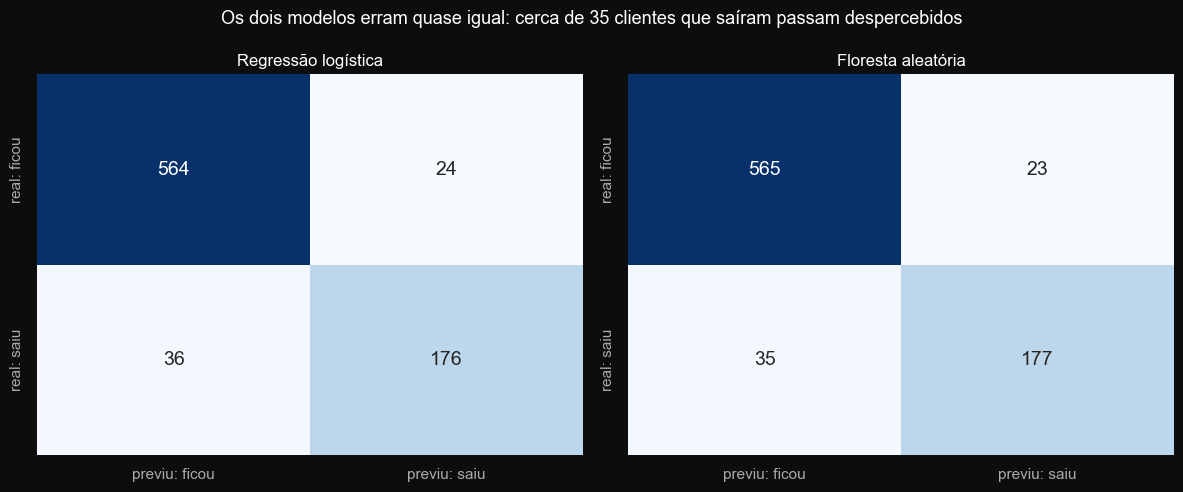


Regressão logística com limiar 0.3:
               limiar 0,5 (padrão)  limiar 0.3
precisão                      0.88       0.823
sensibilidade                 0.83       0.901
Clientes apontados como saída: 200 (limiar 0,5) -> 232 (limiar 0.3)
Atenção: limiar escolhido e medido na mesma validação, resultado otimista.


In [17]:
# --- PARTE 3 — erros em número de clientes ------------------------------------
# ravel() devolve na ordem NV, PF, NF, PV. Dou nome a cada caixa para não
# precisar lembrar a posição na matriz.
def contagens(y_real, y_previsto):
    nv, pf, nf, pv = confusion_matrix(y_real, y_previsto).ravel()
    return {'saíram e o modelo encontrou (PV)': pv,
            'saíram e o modelo deixou passar (NF)': nf,
            'ficaram e o modelo apontou como saída (PF)': pf,
            'ficaram e o modelo acertou (NV)': nv}

erros = pd.DataFrame({'Regressão logística': contagens(y_test, y_pred_logistico),
                    'Floresta aleatória': contagens(y_test, y_pred_floresta)})
print('\nClientes da validação por tipo de acerto e erro:')
print(erros)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nome, y_previsto) in zip(axes, [('Regressão logística', y_pred_logistico),
                                        ('Floresta aleatória', y_pred_floresta)]):
    sns.heatmap(confusion_matrix(y_test, y_previsto), annot=True, fmt='d', cmap='Blues',
                cbar=False, annot_kws={'size': 14}, ax=ax,
                xticklabels=['previu: ficou', 'previu: saiu'],
                yticklabels=['real: ficou', 'real: saiu'])
    ax.set_title(nome)
fig.suptitle('Os dois modelos erram quase igual: cerca de 35 clientes que saíram passam despercebidos',
            fontsize=13, color='#ffffff')
fig.tight_layout()
plt.savefig(f'{PASTA_IMAGENS}/3_4_matrizes_confusao.png')
plt.show()

# --- PARTE 4 — limiar como decisão de negócio ---------------------------------
# predict corta em 0,5. Baixo para 0,3 na logística: aponto mais clientes como
# saída, encontro mais dos que saem e pago com alertas a mais.
# Limitação: escolho o limiar e meço o resultado no mesmo conjunto de validação,
# então os números do limiar 0,3 são um pouco otimistas. O certo seria escolher
# o limiar em dados separados (ou com validação cruzada no treino) e só depois
# medir na validação. Leio este teste como uma ilustração da troca, não como meta.
LIMIAR = 0.3
y_pred_limiar = (y_pred_proba_logistico >= LIMIAR).astype(int)

limiar_tabela = pd.DataFrame({
    'limiar 0,5 (padrão)': [precisao_logistico, sensibilidade_logistico],
    f'limiar {LIMIAR}': [precision_score(y_test, y_pred_limiar), recall_score(y_test, y_pred_limiar)],
}, index=['precisão', 'sensibilidade'])

print(f'\nRegressão logística com limiar {LIMIAR}:')
print(limiar_tabela.round(3))
print(f'Clientes apontados como saída: {y_pred_logistico.sum()} (limiar 0,5) '
    f'-> {y_pred_limiar.sum()} (limiar {LIMIAR})')
print('Atenção: limiar escolhido e medido na mesma validação, resultado otimista.')

In [18]:
# --- PARTE 5 — teste do vazamento: os modelos sem a frequência do mês ---------
# Suspeita da 2.1b: 116 dos 122 clientes que pararam de ir no mês saíram. Se o
# "mês corrente" é o mês da saída, essa coluna entrega a resposta. Retreino os
# dois modelos sem ela, no mesmo split, e comparo. Se as métricas despencarem,
# o modelo dependia do vazamento; se caírem pouco, o sinal vem do resto.
COLUNA_SUSPEITA = 'Avg_class_frequency_current_month'

X_train_sem = X_train.drop(columns=COLUNA_SUSPEITA)
X_test_sem = X_test.drop(columns=COLUNA_SUSPEITA)

# Padronizador novo: o da 3.2 aprendeu com 13 colunas, aqui são 12.
scaler_sem = StandardScaler()
X_train_sem_st = scaler_sem.fit_transform(X_train_sem)
X_test_sem_st = scaler_sem.transform(X_test_sem)

logistico_sem = LogisticRegression(random_state=RANDOM_STATE).fit(X_train_sem_st, y_train)
floresta_sem = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE).fit(X_train_sem, y_train)

# Mesma lista de métricas e mesma ordem da tabela da PARTE 1.
def metricas(modelo, X_val):
    previsto = modelo.predict(X_val)
    proba = modelo.predict_proba(X_val)[:, 1]
    return [accuracy_score(y_test, previsto), precision_score(y_test, previsto),
            recall_score(y_test, previsto), f1_score(y_test, previsto),
            roc_auc_score(y_test, proba)]

teste_vazamento = pd.DataFrame({
    'Logística (com)': comparacao['Regressão logística'],
    'Logística (sem)': metricas(logistico_sem, X_test_sem_st),
    'Floresta (com)': comparacao['Floresta aleatória'],
    'Floresta (sem)': metricas(floresta_sem, X_test_sem),
}, index=comparacao.index)

print(f'\nCom e sem {COLUNA_SUSPEITA} (validação):')
print(teste_vazamento.round(3))

print('\nClientes da validação, modelos sem a coluna:')
print(pd.DataFrame({'Logística (sem)': contagens(y_test, logistico_sem.predict(X_test_sem_st)),
                    'Floresta (sem)': contagens(y_test, floresta_sem.predict(X_test_sem))}))


Com e sem Avg_class_frequency_current_month (validação):
               Logística (com)  Logística (sem)  Floresta (com)  Floresta (sem)
acurácia                 0.925            0.901           0.928           0.904
precisão                 0.880            0.831           0.885           0.861
sensibilidade            0.830            0.788           0.835           0.759
F1                       0.854            0.809           0.859           0.807
ROC-AUC                  0.977            0.957           0.968           0.942

Clientes da validação, modelos sem a coluna:
                                            Logística (sem)  Floresta (sem)
saíram e o modelo encontrou (PV)                        167             161
saíram e o modelo deixou passar (NF)                     45              51
ficaram e o modelo apontou como saída (PF)               34              26
ficaram e o modelo acertou (NV)                         554             562


**Conclusão 3.2, 3.3 e 3.4 — Os dois modelos ficam bem acima da linha de base, a floresta fica à frente por uma margem que não passa de sorteio, e escolho a regressão logística:**

**Os dois modelos.** Treinei uma regressão logística com as características padronizadas (fit só no treino) e uma floresta aleatória com os dados originais, as duas no mesmo split e com `random_state` fixo. Com as 13 características, a floresta se saiu nominalmente melhor: está à frente em acurácia (92,8% contra 92,5%), precisão (88,5% contra 88,0%), sensibilidade (83,5% contra 83,0%) e F1 (0,859 contra 0,854), e a logística só lidera no ROC-AUC (0,977 contra 0,968). Os dois ficam cerca de 19 pontos acima dos 73,5% do chute "ninguém sai". A diferença real está nos clientes que saíram: a linha de base não encontra nenhum, a logística encontra 176 dos 212 (83,0%) e a floresta 177 (83,5%).

**O empate.** Declarei antes que diferenças de até 0,02 contam como sorteio. A maior diferença entre os modelos foi de 0,010, no ROC-AUC, então a vantagem da floresta está dentro da margem. Em clientes, ela acerta 1 a mais entre os que saíram (177 contra 176) e erra 1 a menos entre os que ficaram (23 contra 24 alertas à toa). Com só 212 clientes que saíram na validação, outra divisão poderia inverter essa ordem.

**O teste do vazamento.** A frequência do mês corrente era suspeita desde a seção 2.1, porque quase todos os clientes que pararam de ir no mês saíram. Retreinei os dois modelos sem ela. A logística caiu de 92,5% para 90,1% de acurácia e passou a encontrar 167 dos 212 clientes que saíram (78,8%), 9 a menos, uma queda de 4,2 pontos na sensibilidade. A floresta caiu mais: encontrou 161 (75,9%), 16 a menos, uma queda de 7,6 pontos. Os dois continuam bem acima dos 73,5%, então os modelos dependem dessa coluna menos do que eu temia, mas dependem: a floresta, em especial, perde boa parte da vantagem sem ela. E a frequência total, que tem r = 0,95 com a do mês, continuou no modelo, então o teste mostra que o resultado não vem só do vazamento, não que esteja livre dele.

**Por que escolho a logística.** Pelo desempenho, os dois empatam com uma pequena vantagem nominal da floresta. Escolho a logística por razões secundárias: sem a coluna suspeita ela fica 2,9 pontos à frente na sensibilidade (78,8% contra 75,9%), acima da margem de 0,02, então é a mais estável; ordena um pouco melhor os clientes pela probabilidade de sair (ROC-AUC 0,977 contra 0,968); é mais simples; e tem coeficientes que dá para ler, o que uso na seção 3.5.

**O erro que custa mais caro.** Para a academia, deixar passar quem vai sair custa a mensalidade e o cliente, enquanto um alerta à toa custa uma ação de retenção. Com o corte padrão de 0,5, a logística deixa passar 36 dos 212 clientes que saíram. Baixando o limiar para 0,3, a sensibilidade sobe de 83,0% para 90,1% e a precisão cai de 88,0% para 82,3%, com 232 clientes apontados como saída em vez de 200. Esses números são um pouco otimistas, porque escolhi o limiar e medi o resultado no mesmo conjunto de validação: numa aplicação real, o limiar deveria ser escolhido em dados separados. Se uma ação de retenção custa menos que perder um cliente, um limiar menor tende a compensar (hipótese de custo, o enunciado não informa os valores).

## 3.5 O que pesa no churn

> *Enunciado: "Analise os fatores que mais impactam a rotatividade"*

In [19]:
# -----------------------------------------------------------------------------
# 3.5 O que pesa no churn — coeficientes e importâncias
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Comparo duas leituras: coef_ da logística (com sinal, dados padronizados)
# e feature_importances_ da floresta (sem sinal, soma 1). Onde as duas
# concordam, o fator é robusto. Cuidado com as gêmeas da 2.4: a logística
# pode dividir o peso entre elas ou inverter um sinal. Importância não é causa.

# --- PARTE 1 — coeficientes da logística --------------------------------------
# X_train_st perdeu os nomes; pego de X_train.columns, na mesma ordem.
# key=abs ordena pelo tamanho sem perder o sinal.
coeficientes_logistico = (
    pd.Series(modelo_logistico.coef_[0], index=X_train.columns)
    .sort_values(key=abs, ascending=False)
)
print('Coeficientes da logística (negativo = reduz a chance de sair):')
print(coeficientes_logistico.round(2), '\n')

# --- PARTE 2 — importâncias da floresta ---------------------------------------
# Sempre positivas, então ordeno direto pelo valor.
importancias_floresta = (
    pd.Series(modelo_floresta.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)
print('Importâncias da floresta (sem sinal, somam 1):')
print(importancias_floresta.round(3))

Coeficientes da logística (negativo = reduz a chance de sair):
Avg_class_frequency_current_month   -4.22
Lifetime                            -3.77
Avg_class_frequency_total            3.14
Age                                 -1.19
Contract_period                     -0.67
Month_to_end_contract               -0.63
Avg_additional_charges_total        -0.58
Group_visits                        -0.37
Promo_friends                       -0.22
Partner                             -0.04
Near_Location                       -0.03
Phone                               -0.03
gender                               0.02
dtype: float64 

Importâncias da floresta (sem sinal, somam 1):
Lifetime                             0.281
Avg_class_frequency_current_month    0.162
Age                                  0.134
Avg_class_frequency_total            0.129
Avg_additional_charges_total         0.089
Month_to_end_contract                0.069
Contract_period                      0.067
Group_visits              

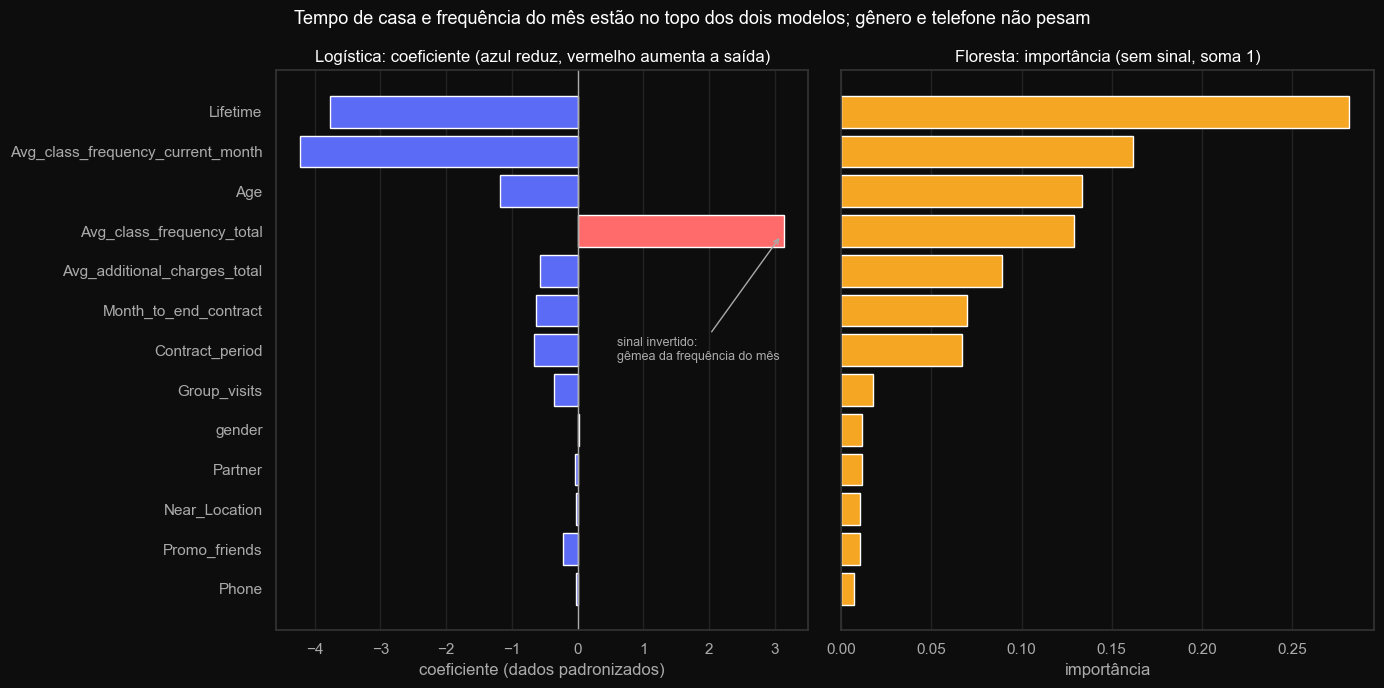

In [20]:
# --- PARTE 3 — gráfico lado a lado --------------------------------------------
# Mesma ordem de linhas nos dois painéis (a da floresta), para comparar fator
# por fator. Na logística: azul = reduz a chance de sair, vermelho = aumenta.
ordem = importancias_floresta.index[::-1]   # invertido: o barh desenha de baixo para cima
coef_ordenado = coeficientes_logistico[ordem]
cores_coef = ['#FF6B6B' if valor > 0 else '#5B6BF5' for valor in coef_ordenado]

fig, (ax_log, ax_flo) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

ax_log.barh(ordem, coef_ordenado, color=cores_coef)
ax_log.axvline(0, color='#aaaaaa', linewidth=1)
ax_log.set_title('Logística: coeficiente (azul reduz, vermelho aumenta a saída)')
ax_log.set_xlabel('coeficiente (dados padronizados)')
ax_log.grid(axis='x')
ax_log.grid(axis='y', visible=False)
# Texto no espaço vazio à direita, abaixo da barra, com a seta até a ponta dela.
ax_log.annotate('sinal invertido:\ngêmea da frequência do mês',
                xy=(coef_ordenado['Avg_class_frequency_total'], 'Avg_class_frequency_total'),
                xytext=(0.6, 'Contract_period'), color='#aaaaaa', fontsize=9,
                ha='left', va='center',
                arrowprops=dict(arrowstyle='->', color='#aaaaaa', shrinkB=6))

ax_flo.barh(ordem, importancias_floresta[ordem], color='#F5A623')
ax_flo.set_title('Floresta: importância (sem sinal, soma 1)')
ax_flo.set_xlabel('importância')
ax_flo.grid(axis='x')
ax_flo.grid(axis='y', visible=False)

fig.suptitle('Tempo de casa e frequência do mês estão no topo dos dois modelos; gênero e telefone não pesam',
            fontsize=13, color='#ffffff')
fig.tight_layout()
plt.savefig(f'{PASTA_IMAGENS}/3_5_fatores.png')
plt.show()

**Conclusão 3.5 — Tempo de casa e frequência no mês são os fatores que mais pesam nos dois modelos; a idade pesa, mas com menos consenso:**

**Os fatores principais.** Comparei as primeiras posições dos dois rankings. Na logística, pelo tamanho do coeficiente, a ordem é frequência no mês corrente (−4,22), tempo de casa (−3,77), frequência total (+3,14) e só depois a idade (−1,19). Na floresta, a ordem é tempo de casa (0,281), frequência no mês corrente (0,162), idade (0,134) e frequência total (0,129). Os dois modelos concordam nos dois primeiros: tempo de casa e frequência no mês ficam no topo dos dois, com sinal negativo na logística, ou seja, quanto mais tempo de casa e mais visitas no mês, menor a chance de sair. Esses dois considero robustos. A idade é a terceira na floresta, mas a quarta na logística, atrás de uma frequência total cujo coeficiente está distorcido pela gêmea: ela pesa nos dois modelos, mas não com o mesmo consenso.

**O que pesa pouco ou nada.** Gênero e telefone ficam no fim nos dois modelos (coeficientes de 0,02 e −0,03, importâncias de 0,011 e 0,007), o mesmo que as barras da 2.3 e a correlação da 2.4 já mostravam. Os laços sociais, que separavam bem nas barras da 2.3, pesam pouco aqui: a aula em grupo tem coeficiente −0,37 e importância 0,018, e a parceria tem −0,04 e 0,011. Uma explicação provável é que eles andam junto com o contrato longo (r entre 0,24 e 0,31 na 2.4), e o modelo prefere a informação do contrato (hipótese).

**Onde as gêmeas atrapalham.** Na logística, a frequência total aparece com coeficiente positivo (+3,14), como se ir mais à academia aumentasse a saída. Isso contradiz a correlação de −0,25 da 2.4 e as médias da 2.2. É a multicolinearidade: com r = 0,95 entre as duas frequências, o modelo usa a do mês com peso negativo grande e compensa com a total positiva. O que ele aprendeu de fato é a queda no último mês em relação à média do cliente, e os dois coeficientes não devem ser lidos separados. Na floresta, contrato e meses restantes dividem a importância (0,067 e 0,069). Somados dão 0,136, o que colocaria o contrato junto da idade entre os principais fatores.

**Os limites.** Importância não é causa: os modelos mostram o que ajuda a prever a saída, não o que a provoca. E a frequência no mês, um dos dois fatores principais, é a coluna suspeita de vazamento (seção 3.4). Sem ela os modelos continuam bem acima da linha de base, mas perdem parte do desempenho, e o peso dela aqui pode estar maior do que seria numa previsão feita antes do mês começar.

---

# 4. Agrupamento de clientes

> **Enunciado (Passo 4):** Defina ao lado colunas com dados sobre rotatividade e identifique agrupamentos do
> objeto (cliente): Padronize os dados. Use a função `linkage()` para construir a matriz das distâncias
> baseada na matriz de características padronizada e construa um dendrograma. Treine o modelo de agrupamento
> com o algoritmo K-means e preveja agrupamentos de clientes (`n=5`). Olhe para os valores médios das
> características para agrupamentos. Faça distribuições de características para os agrupamentos. Calcule a
> taxa de rotatividade para cada agrupamento (use o método `groupby()`). Quais agrupamentos são propensos a
> sair, e quais são leais?

Aqui deixo a previsão de lado e procuro tipos de cliente. Tiro a coluna `Churn` antes de agrupar, porque quero que os grupos saiam do perfil e do comportamento de cada cliente, não da resposta que depois vou medir. Se o `Churn` entrasse, ele ajudaria a formar os grupos e a taxa de saída de cada um ficaria decidida de antemão. Ele só volta no fim, na 4.6, para medir quantos clientes saíram em cada grupo.

## 4.1 Padronizar sem o Churn

> *Enunciado: "Defina ao lado colunas com dados sobre rotatividade [...] Padronize os dados."*

In [21]:
# -----------------------------------------------------------------------------
# 4.1 Padronizar sem o Churn
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Tiro a coluna Churn antes de agrupar: os grupos têm de sair do perfil e do
# comportamento, e o churn só volta depois, para medir cada grupo.
# Padronizo porque K-Means e o hierárquico usam distância, e sem escala a
# coluna de gastos (centenas) domina a idade e as binárias.

# --- PARTE 1 — matriz sem Churn -----------------------------------------------
# Variável nova: o X da seção 3 fica intacto.
X_cluster = gym.drop(columns='Churn')
print('Matriz para agrupar:', X_cluster.shape, '| Churn de fora:', 'Churn' not in X_cluster.columns)

# --- PARTE 2 — StandardScaler -------------------------------------------------
# Aqui não existe treino e validação: o agrupamento descreve a base inteira,
# então o fit_transform em todos os clientes é o correto (não há o que vazar).
scaler_cluster = StandardScaler()
X_cluster_st = scaler_cluster.fit_transform(X_cluster)

# Conferência: depois de padronizar, toda coluna tem média 0 e desvio 1.
print(f'Maior |média| entre as colunas: {np.abs(X_cluster_st.mean(axis=0)).max():.3f}')
print(f'Desvios entre {X_cluster_st.std(axis=0).min():.3f} e {X_cluster_st.std(axis=0).max():.3f}')

Matriz para agrupar: (4000, 13) | Churn de fora: True
Maior |média| entre as colunas: 0.000
Desvios entre 1.000 e 1.000


**Conclusão 4.1 — Agrupei os clientes sem o Churn e com todas as colunas na mesma escala:**

**Por que o Churn ficou de fora.** Quero que os grupos saiam do perfil e do comportamento do cliente, não da resposta que depois vou medir. Se o `Churn` entrasse, ele ajudaria a formar os grupos e a taxa de saída de cada um ficaria combinada de antemão. Ele só volta na 4.6, para medir quantos saíram em cada grupo. A matriz de agrupamento ficou com os 4.000 clientes e as 13 características, sem o `Churn`.

**Por que padronizar.** O K-Means e o dendrograma medem distância entre clientes. Sem padronizar, o gasto com serviços extras, que vai até 552, dominaria a conta, e uma diferença de 0 para 1 em `Partner` ou `Promo_friends` quase não pesaria. Depois da padronização todas as colunas têm média 0 e desvio 1. Na floresta aleatória isso não era preciso, porque ela decide por cortes em uma coluna de cada vez e não compara distâncias.

**Por que padronizei a base inteira.** Na seção 3 o padronizador só aprendia com o treino, para a validação não vazar. Aqui não há validação: o agrupamento descreve os clientes que já existem, não prevê clientes novos, então ajustar o padronizador nos 4.000 clientes é o correto. As colunas binárias passam a ter dois valores "tortos" em vez de 0 e 1, o que é normal e não muda a leitura, porque o perfil da 4.4 volta para as unidades originais.

## 4.2 Dendrograma

> *Enunciado: "Use a função linkage() para construir a matriz das distâncias [...] e construa um dendrograma. Use o gráfico resultante para estimar o número de agrupamentos que você pode destacar."*

Maior salto: 17.3 (de 66.6 para 83.9)
Cortando no meio desse salto (altura 75.2): 4 grupos

Folga de cada número de grupos: distância entre a fusão que cria k grupos e a que os reduz a k-1 
(maior = corte mais natural)
2    15.7
3     5.1
4    17.3
5     6.7
6    11.2
7     4.5
8     2.9
9     1.4
dtype: float64


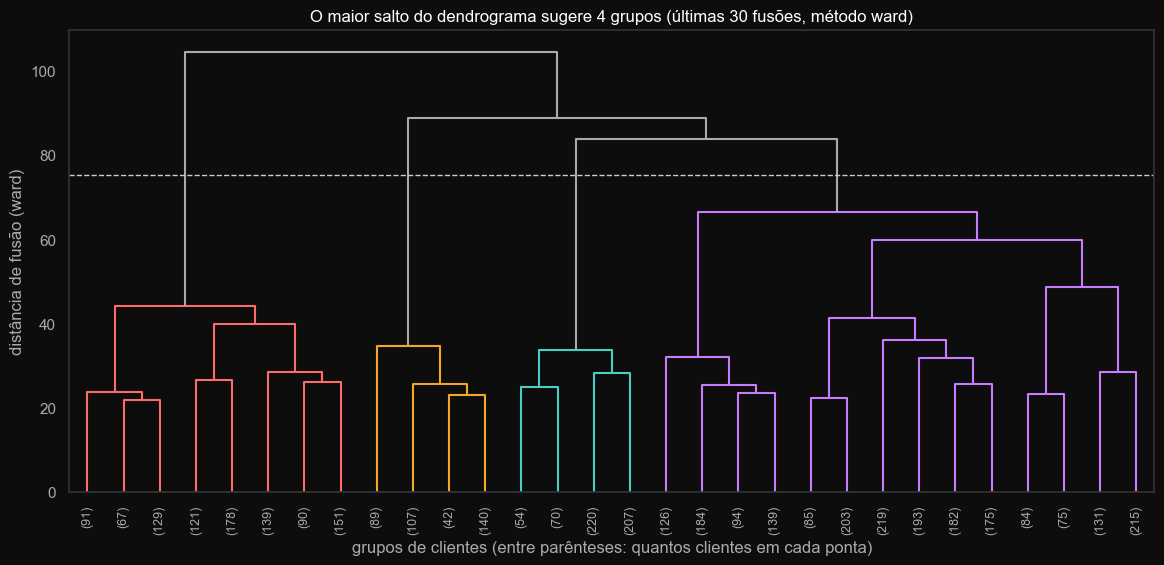

In [22]:
# -----------------------------------------------------------------------------
# 4.2 Dendrograma
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# linkage com method='ward' sobre a matriz padronizada. Com 4.000 linhas o
# desenho completo é lento e ilegível, então uso truncate_mode='lastp' para
# mostrar só as últimas fusões. Leio o número de grupos pelo maior salto
# vertical e marco o corte com uma linha cinza clara.

# --- PARTE 1 — linkage --------------------------------------------------------
# Ward junta, a cada passo, os dois grupos que menos aumentam a variância
# interna. A coluna 2 de linked é a altura (distância) de cada fusão.
linked = linkage(X_cluster_st, method='ward')

# Calculo o maior salto em vez de só olhar o desenho: entre duas fusões
# seguidas, o maior aumento de altura é onde vale cortar.
ULTIMAS_FUSOES = 30
alturas = linked[-ULTIMAS_FUSOES:, 2]
saltos = np.diff(alturas)
posicao_maior_salto = np.argmax(saltos)
n_grupos_sugerido = ULTIMAS_FUSOES - posicao_maior_salto
altura_corte = (alturas[posicao_maior_salto] + alturas[posicao_maior_salto + 1]) / 2

print(f'Maior salto: {saltos.max():.1f} (de {alturas[posicao_maior_salto]:.1f} '
      f'para {alturas[posicao_maior_salto + 1]:.1f})')
print(f'Cortando no meio desse salto (altura {altura_corte:.1f}): {n_grupos_sugerido} grupos')

# Para comparar com os 5 do enunciado: o salto que separa k grupos de k-1.
saltos_por_k = pd.Series(saltos[::-1][:8], index=range(2, 10)).round(1)
print('\nFolga de cada número de grupos: distância entre a fusão que cria k grupos e a que os reduz a k-1 '
      '\n(maior = corte mais natural)')
print(saltos_por_k)

# --- PARTE 2 — dendrograma truncado + linha de corte --------------------------
# As cores abaixo do corte só marcam os ramos do hierárquico; não são os
# grupos do K-Means da 4.3 (aquele usa as cores de CORES por número de grupo).
plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=ULTIMAS_FUSOES,
      color_threshold=altura_corte, above_threshold_color='#aaaaaa',
      leaf_rotation=90, leaf_font_size=9)
plt.axhline(altura_corte, color='#cccccc', linestyle='--', linewidth=1)
plt.title(f'O maior salto do dendrograma sugere {n_grupos_sugerido} grupos '
      f'(últimas {ULTIMAS_FUSOES} fusões, método ward)')
plt.xlabel('grupos de clientes (entre parênteses: quantos clientes em cada ponta)')
plt.ylabel('distância de fusão (ward)')
plt.grid(False)
plt.savefig(f'{PASTA_IMAGENS}/4_2_dendrograma.png')
plt.show()

**Conclusão 4.2 — O dendrograma sugere 4 grupos, e os 5 do enunciado não aparecem com clareza nos dados:**

**Como li o dendrograma.** O método ward junta, a cada passo, os dois grupos mais parecidos, até sobrar um só, e anota a distância de cada fusão. Desenhei só as últimas 30 fusões, porque com 4.000 clientes a árvore inteira fica ilegível. Em vez de escolher o corte só no olho, calculei onde a distância sobe mais de uma fusão para a seguinte: é ali que o algoritmo passa a juntar grupos bem diferentes.

**Quantos grupos.** O maior salto foi de 17,3 (a distância passa de 66,6 para 83,9), e cortando no meio dele, na altura 75,2, sobram 4 grupos. O corte em 2 grupos também é forte, com salto de 15,7. Já o corte em 5, o número fixado pelo enunciado, tem um salto de só 6,7: o quinto grupo sairia de dentro de um galho grande, separando clientes que ainda são parecidos entre si.

**O que isso muda.** Sigo com os 5 grupos na 4.3 porque o enunciado pede, mas registro que esse número vem da tarefa, não dos dados. Espero grupos com fronteiras pouco nítidas, o que confiro com a silhueta na 4.3.

## 4.3 K-Means com 5 grupos

> *Enunciado: "Treine o modelo de agrupamento com o algoritmo K-means e preveja agrupamentos de clientes. (Deixe que o número de agrupamentos seja n=5 [...])"*

In [23]:
# -----------------------------------------------------------------------------
# 4.3a Ponto de partida fixo do K-Means
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# O K-Means depende de onde os centros começam, e o sorteio do k-means++ mudou
# entre versões do sklearn: com o mesmo random_state, a plataforma (0.24) e o meu
# computador (1.7) chegavam a divisões diferentes. Por isso fixo o ponto de
# partida: são os centros finais de KMeans(n_init=10, random_state=42) no 1.7,
# na matriz padronizada. Guardo com o nome de cada coluna, para não depender
# da ordem delas.

CENTROS_INICIAIS = pd.DataFrame([
    [-0.027859, -2.337100, -0.039690, -0.500773,  0.040441, -0.543332, -0.400570, -0.215102, -0.138188, -0.536708, -0.251681, -0.227710, -0.285134],
    [-0.022642,  0.274271,  0.507447,  0.382231, -0.009682,  1.583458,  0.282448,  0.229399,  0.183530,  1.564004,  0.253253,  0.123534,  0.212262],
    [-0.046785,  0.423607,  0.671249,  1.497161, -0.018658, -0.333901,  0.091919,  0.015556, -0.051850, -0.333705,  0.002510, -0.139409, -0.122732],
    [-0.044060,  0.427881, -0.486352, -0.622825, -0.004491, -0.592782, -0.184244, -0.299548, -0.162733, -0.578029, -0.359082, -0.626516, -0.702468],
    [ 0.149883,  0.348779, -0.456105, -0.476479,  0.005322, -0.411024,  0.126752,  0.289902,  0.151618, -0.413378,  0.383189,  1.027461,  1.055095],
], columns=['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period',
            'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract',
            'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month'])

# Confiro que os centros têm exatamente as colunas da matriz de agrupamento.
assert set(CENTROS_INICIAIS.columns) == set(X_cluster.columns), 'colunas dos centros não batem'
print('Centros iniciais:', CENTROS_INICIAIS.shape, '| colunas conferidas com X_cluster')

Centros iniciais: (5, 13) | colunas conferidas com X_cluster


In [24]:
# -----------------------------------------------------------------------------
# 4.3 K-Means com 5 grupos
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# KMeans(n_clusters=N_CLUSTERS) na matriz padronizada, com ponto de partida fixo.
# Guardo o rótulo numa coluna nova do DataFrame original (cópia), para ler
# o perfil em unidades reais. Meço a silhueta e o tamanho de cada grupo.

# --- PARTE 1 — treino e rótulos -----------------------------------------------
# Começo dos centros da 4.3a, na ordem das colunas do X_cluster. tol=0 faz o
# algoritmo rodar até os grupos pararem de mudar, então qualquer versão do
# sklearn chega ao mesmo resultado.
modelo_kmeans = KMeans(n_clusters=N_CLUSTERS, init=CENTROS_INICIAIS[X_cluster.columns].to_numpy(),
                       n_init=1, tol=0, max_iter=1000, random_state=RANDOM_STATE)
rotulos_cluster = modelo_kmeans.fit_predict(X_cluster_st)

# Cópia do gym com a coluna cluster: o gym original não muda.
# "cluster" é o nome técnico de "grupo": no código uso cluster, no texto, grupo.
# O número (0 a 4) é só um rótulo, sem ordem: o grupo 4 não é "maior" que o 0.
gym_clusters = gym.copy()
gym_clusters['cluster'] = rotulos_cluster

# --- PARTE 2 — tamanho de cada grupo (absoluto e relativo) --------------------
tamanho_cluster = gym_clusters['cluster'].value_counts().sort_index()
print('Clientes por grupo:')
print(pd.DataFrame({'clientes': tamanho_cluster,
                    '% da base': (tamanho_cluster / len(gym_clusters) * 100).round(1)}))

# --- PARTE 3 — silhueta -------------------------------------------------------
# Silhueta vai de -1 a 1. Perto de 1 = cada cliente bem mais perto do próprio
# grupo do que do vizinho. Limiar declarado antes: abaixo de 0,25 = estrutura fraca.
LIMIAR_SILHUETA_FRACA = 0.25
silhueta = silhouette_score(X_cluster_st, rotulos_cluster)

print(f'\nSilhueta média: {silhueta:.3f}')
print(f'Veredito: {"estrutura fraca" if silhueta < LIMIAR_SILHUETA_FRACA else "estrutura razoável"} '
      f'(limiar {LIMIAR_SILHUETA_FRACA})')

Clientes por grupo:
         clientes  % da base
cluster                     
0             544       13.6
1             938       23.4
2             642       16.0
3            1108       27.7
4             768       19.2



Silhueta média: 0.128
Veredito: estrutura fraca (limiar 0.25)



**Conclusão 4.3 — O K-Means formou 5 grupos de tamanho equilibrado, mas com fronteiras fracas:**

**Os grupos.** Chamo de grupo o que o código chama de cluster. Treinei o K-Means com os 5 grupos do enunciado e um ponto de partida fixo, porque o sorteio inicial muda entre versões do sklearn e cada versão chegava a uma divisão diferente. Assim os grupos saem iguais em qualquer execução. O maior é o grupo 3, com 1.108 clientes (27,7% da base), e o menor é o grupo 0, com 544 (13,6%). Os outros ficam entre os dois: o grupo 1 com 938 (23,4%), o grupo 4 com 768 (19,2%) e o grupo 2 com 642 (16,0%). Nenhum grupo é pequeno demais para virar público de uma ação de retenção.

**A separação.** A silhueta média foi de 0,128, abaixo do limiar de 0,25 que declarei antes, então a estrutura é fraca: boa parte dos clientes está perto da fronteira entre dois grupos. Isso confirma o que o dendrograma da 4.2 já mostrava, que os 5 grupos vêm do enunciado e não de uma divisão natural dos dados.

**Como vou ler os grupos.** Com fronteiras fracas, trato cada grupo como uma tendência ("o grupo 3 tende a ter contrato curto"), não como uma categoria rígida. O que decide se os grupos servem para o negócio é a 4.6: se a taxa de saída mudar muito de um grupo para outro, eles são úteis mesmo com a silhueta baixa.

## 4.4 Perfil médio por grupo

> *Enunciado: "Olhe para os valores médios das características para agrupamentos. Nada chama a sua atenção?"*

In [25]:
# -----------------------------------------------------------------------------
# 4.4 Perfil médio por grupo
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# groupby(cluster).mean() nas unidades originais, não nas padronizadas,
# para ler "idade 30", "contrato 12 meses". Destaco por coluna o maior e o
# menor valor entre os grupos para achar o traço de cada um.

# --- PARTE 1 — médias por grupo -----------------------------------------------
# Churn fica de fora: ele só entra na 4.6. Transponho para ler uma
# característica por linha e um grupo por coluna.
perfil_cluster = gym_clusters.drop(columns='Churn').groupby('cluster').mean().T

# --- PARTE 2 — tabela com destaque de máximo e mínimo -------------------------
# Verde = o grupo com a maior média naquela característica; roxo = a menor.
display(
    perfil_cluster.style
    .format('{:.2f}')
    .highlight_max(axis=1, props='background-color:#1f5c4a; font-weight:bold')
    .highlight_min(axis=1, props='background-color:#4b2a63')
)

# O mesmo destaque em texto, para não depender só das cores.
for grupo in perfil_cluster.columns:
    maiores = perfil_cluster.index[perfil_cluster.idxmax(axis=1) == grupo].tolist()
    menores = perfil_cluster.index[perfil_cluster.idxmin(axis=1) == grupo].tolist()
    print(f'Grupo {grupo}: maior em {maiores or "nada"} | menor em {menores or "nada"}')

cluster,0,1,2,3,4
gender,0.50,0.50,0.48,0.49,0.59
Near_Location,0.00,0.94,1.00,1.00,0.97
Partner,0.47,0.74,0.82,0.24,0.26
Promo_friends,0.08,0.49,1.00,0.02,0.09
Phone,0.92,0.90,0.90,0.90,0.90
Contract_period,2.21,11.87,3.16,1.99,2.81
Group_visits,0.22,0.55,0.45,0.32,0.48
Age,28.48,29.93,29.22,28.21,30.14
Avg_additional_charges_total,133.63,164.87,141.20,131.19,162.01
Month_to_end_contract,2.07,10.87,2.92,1.90,2.59


Grupo 0: maior em ['Phone'] | menor em ['Near_Location', 'Group_visits']
Grupo 1: maior em ['Contract_period', 'Group_visits', 'Avg_additional_charges_total', 'Month_to_end_contract'] | menor em ['Phone']
Grupo 2: maior em ['Partner', 'Promo_friends'] | menor em ['gender']
Grupo 3: maior em ['Near_Location'] | menor em ['Partner', 'Promo_friends', 'Contract_period', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
Grupo 4: maior em ['gender', 'Age', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month'] | menor em nada


**Conclusão 4.4 — Cada grupo tem um cliente típico bem diferente: de longe, de contrato anual, indicado, de pouco vínculo ou assíduo:**

Novamente chamo de grupo o que o código chama de cluster. Os números abaixo são as médias de cada grupo; nas colunas de sim ou não, a média é a porcentagem de clientes com a característica. Nas médias de contrato, lembro que só existem contratos de 1, 6 e 12 meses (seção 1.1): uma média como 3,16 meses não é o contrato de ninguém, é uma mistura de contratos diferentes, e a composição de cada grupo está na 4.5.

**Grupo 0, os de longe (544 clientes, 13,6%).** O cliente típico não mora nem trabalha perto da academia: nenhum dos 544 tem `Near_Location`. Tem 28 anos e meio, contrato médio de cerca de 2 meses (uma mistura de contratos, a maioria mensal) e está há 2,78 meses na academia. Raramente veio por indicação (8%) e pouco faz aula em grupo (22%). Vai 1,47 vez por semana no mês corrente.

**Grupo 1, os de contrato anual (938 clientes, 23,4%).** O cliente típico fechou o contrato longo: 11,87 meses em média, com 10,87 ainda pela frente, quando nos outros grupos o contrato fica entre 1,99 e 3,16 meses. Três em cada quatro são de empresa parceira (74%), metade veio por indicação (49%) e mais da metade faz aula em grupo (55%). É o que mais gasta com serviços extras (164,87) e vai cerca de 2 vezes por semana.

**Grupo 2, os indicados (642 clientes, 16,0%).** O cliente típico chegou por um amigo: 100% vieram por indicação, 82% são de empresa parceira e praticamente todos moram ou trabalham perto (99,8%). Tem contrato médio de 3,16 meses, que é uma mistura de contratos mensais e semestrais, e não um contrato de 3 meses. Tem 29 anos e está há 3,71 meses na academia. Vai 1,63 vez por semana no mês corrente.

**Grupo 3, os de pouco vínculo (1.108 clientes, 27,7%).** É o maior grupo e o cliente típico é o mais solto de todos. Mora perto (100%), mas quase nunca veio por indicação (2%) e só 24% são de empresa parceira. Tem o contrato mais curto (1,99 mês), o menor tempo de casa (2,40 meses), é o mais novo (28,21 anos) e o que menos frequenta: 1,03 vez por semana no mês corrente, abaixo da própria média total de 1,27.

**Grupo 4, os assíduos (768 clientes, 19,2%).** O cliente típico tem o hábito de treinar: vai 2,88 vezes por semana, tanto na média total quanto no mês corrente, e está há 5,13 meses na academia, o maior tempo de casa. É o mais velho (30,14 anos) e gasta bem com serviços extras (162,01). O curioso é que tem contrato médio curto (2,81 meses, também uma mistura de contratos, a maioria mensal) e pouca parceria (26%) ou indicação (9%): o vínculo parece vir do hábito, não do contrato (hipótese).

**O que não separa os grupos.** O telefone fica perto de 90% em todos. O gênero só muda no grupo 4 (59% com código 1, contra cerca de 50% nos outros), e como o enunciado não diz qual código é qual gênero, não dá para ir além disso, recomendaria criar uma divisão correta de gêneros para facilitar futuras campanhas e análise mais profunda de cada cliente.

## 4.5 Distribuições por grupo

> *Enunciado: "Faça distribuições de características para os agrupamentos. Você notou alguma coisa?"*

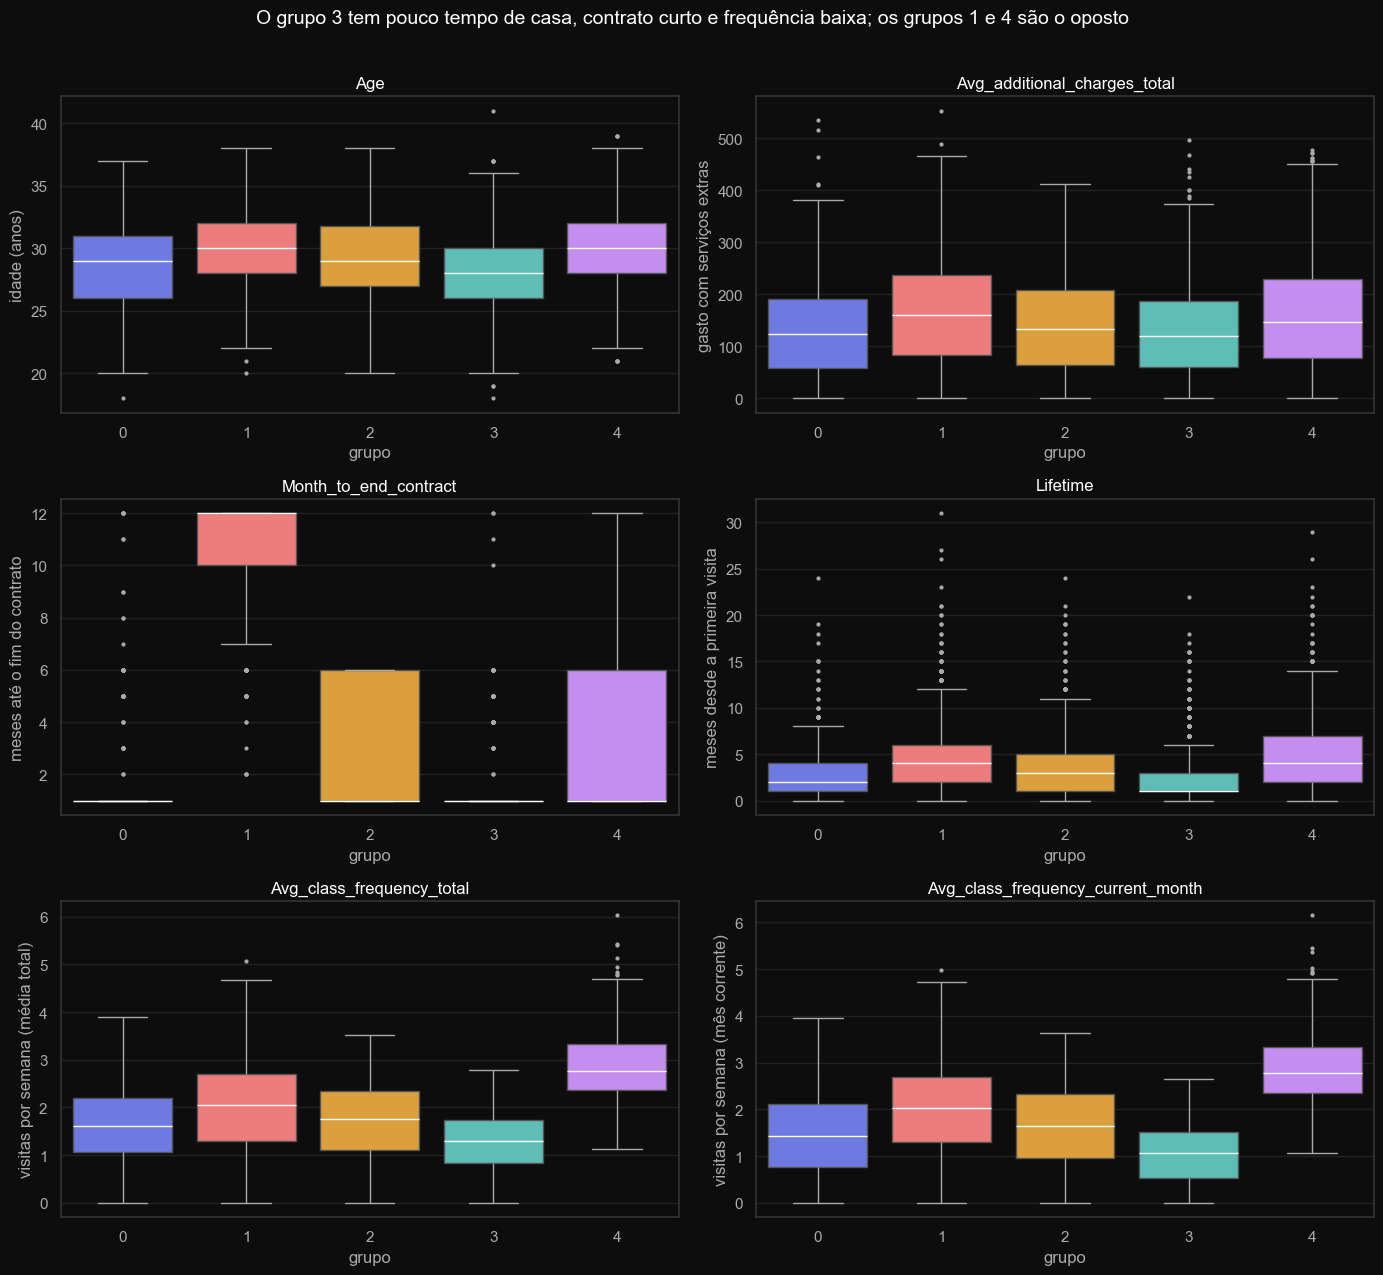

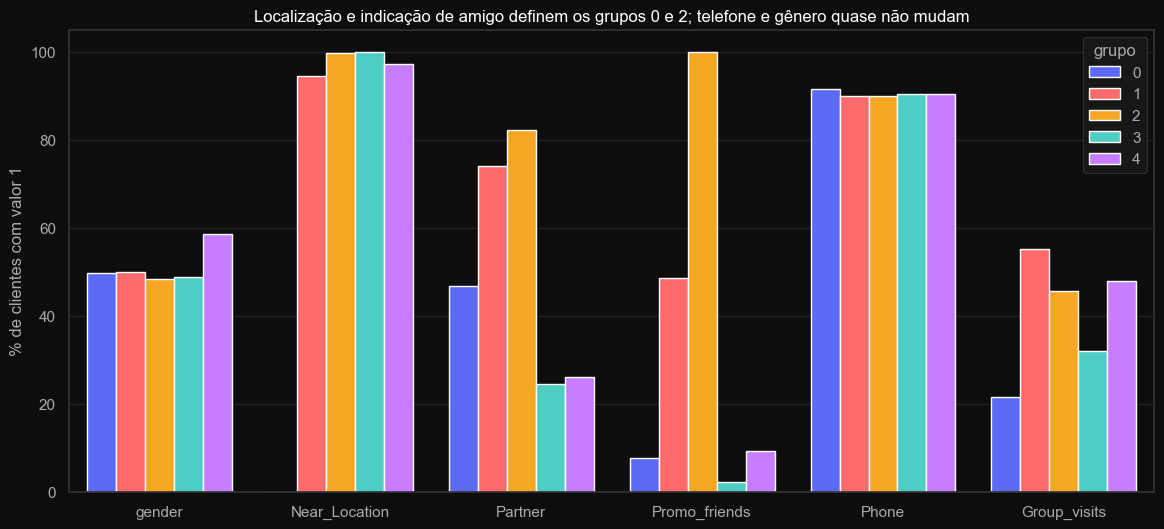

% de clientes com valor 1, por grupo:
cluster           0     1      2      3     4
gender         49.6  50.0   48.4   48.8  58.6
Near_Location   0.0  94.5   99.8  100.0  97.1
Partner        46.7  74.1   82.2   24.4  26.0
Promo_friends   7.7  48.6  100.0    2.1   9.2
Phone          91.5  90.0   90.0   90.3  90.4
Group_visits   21.5  55.2   45.5   32.0  47.8


In [26]:
# -----------------------------------------------------------------------------
# 4.5 Distribuições por grupo
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Contínuas: boxplot por grupo. Binárias: proporção por grupo.
# Cada grupo com a sua cor de CORES, sempre na mesma ordem.
# O objetivo é confirmar (ou desmentir) o que as médias da 4.4 sugeriram.

# Reaproveito as listas da 2.3 (continuous_columns, columns_bar) e o UNIDADE.
COR_CLUSTER = {grupo: CORES[grupo] for grupo in range(N_CLUSTERS)}
ordem_cluster = list(range(N_CLUSTERS))

# --- PARTE 1 — contínuas por grupo --------------------------------------------
# Boxplot: a caixa mostra onde estão os 50% do meio; a linha branca é a mediana.
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for ax, col in zip(axes.flat, continuous_columns):
    sns.boxplot(data=gym_clusters, x='cluster', y=col, hue='cluster', order=ordem_cluster,
                palette=COR_CLUSTER, legend=False, ax=ax,
                flierprops={'markersize': 2, 'markerfacecolor': '#aaaaaa', 'markeredgecolor': '#aaaaaa'},
                medianprops={'color': '#ffffff'}, whiskerprops={'color': '#aaaaaa'},
                capprops={'color': '#aaaaaa'})
    ax.set_title(col)
    ax.set_xlabel('grupo')
    ax.set_ylabel(UNIDADE[col].replace(' (unidade monetária não informada)', ''))
fig.suptitle('O grupo 3 tem pouco tempo de casa, contrato curto e frequência baixa; os grupos 1 e 4 são o oposto', fontsize=14, color='#ffffff')
fig.tight_layout(rect=[0, 0, 1, 0.97])   # deixo espaço para o título geral
plt.savefig(f'{PASTA_IMAGENS}/4_5_continuas_por_grupo.png')
plt.show()

# --- PARTE 2 — binárias por grupo ---------------------------------------------
# % de clientes com valor 1 em cada grupo (a média de uma 0/1 é a proporção).
# Contract_period não é 0/1: a média dele está na tabela da 4.4.
binarias = [col for col in columns_bar if col != 'Contract_period']
proporcao_binarias = (gym_clusters.groupby('cluster')[binarias].mean() * 100).round(1)
proporcao_longa = proporcao_binarias.reset_index().melt(
    id_vars='cluster', var_name='característica', value_name='% com valor 1')

plt.figure(figsize=(14, 6))
sns.barplot(data=proporcao_longa, x='característica', y='% com valor 1', hue='cluster',
            hue_order=ordem_cluster, palette=COR_CLUSTER, order=binarias, saturation=1)
plt.title('Localização e indicação de amigo definem os grupos 0 e 2; telefone e gênero quase não mudam')
plt.xlabel('')
plt.ylabel('% de clientes com valor 1')
plt.legend(title='grupo')
plt.savefig(f'{PASTA_IMAGENS}/4_5_binarias_por_grupo.png')
plt.show()

print('% de clientes com valor 1, por grupo:')
print(proporcao_binarias.T)

Clientes por tipo de contrato (meses), por grupo:
Contract_period   1    6    12
cluster                       
0                428  103   13
1                  0   20  918
2                370  268    4
3                898  203    7
4                511  239   18

Mesma tabela em % de cada grupo:
Contract_period    1     6     12
cluster                          
0                78.7  18.9   2.4
1                 0.0   2.1  97.9
2                57.6  41.7   0.6
3                81.0  18.3   0.6
4                66.5  31.1   2.3


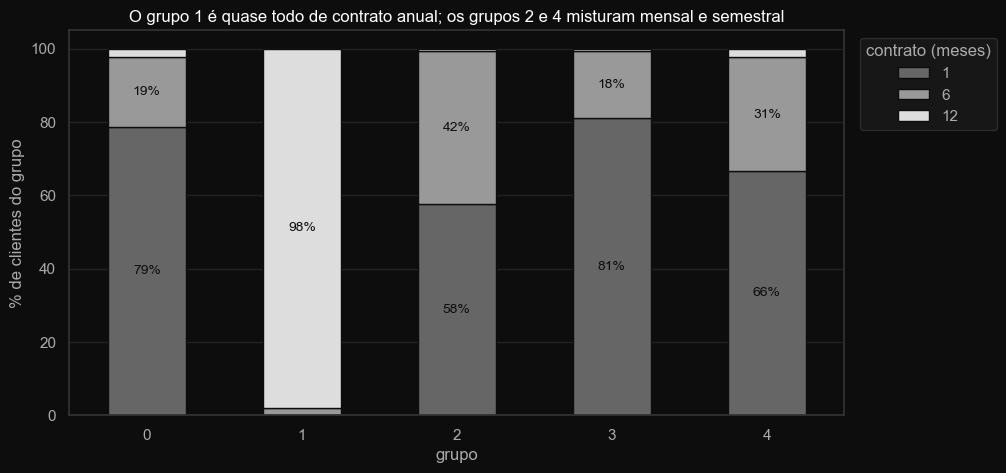

In [27]:
# -----------------------------------------------------------------------------
# 4.5b Tipos de contrato por grupo
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Contract_period não entrou nos gráficos acima: não é contínua nem 0/1, só
# tem 1, 6 e 12 meses. Conto quantos clientes de cada grupo têm cada contrato,
# em número e em %, para sustentar a leitura das médias de contrato da 4.4.

contrato_cluster = pd.crosstab(gym_clusters['cluster'], gym_clusters['Contract_period'])
contrato_cluster_pct = (pd.crosstab(gym_clusters['cluster'], gym_clusters['Contract_period'],
                                    normalize='index') * 100).round(1)
print('Clientes por tipo de contrato (meses), por grupo:')
print(contrato_cluster)
print('\nMesma tabela em % de cada grupo:')
print(contrato_cluster_pct)

# Barras empilhadas: cada barra é um grupo e soma 100%. Tons de cinza para o
# contrato, para não confundir com as cores dos grupos nem com ficou/saiu.
COR_CONTRATO = {1: '#666666', 6: '#999999', 12: '#dddddd'}
ax = contrato_cluster_pct.plot(kind='bar', stacked=True, figsize=(10, 5), rot=0,
                               color=[COR_CONTRATO[c] for c in contrato_cluster_pct.columns],
                               edgecolor='#0d0d0d')
ax.xaxis.grid(False)
# Rótulo em cada pedaço com pelo menos 5% (os menores não cabem).
for i, grupo in enumerate(contrato_cluster_pct.index):
    base = 0
    for contrato in contrato_cluster_pct.columns:
        valor = contrato_cluster_pct.loc[grupo, contrato]
        if valor >= 5:
            ax.text(i, base + valor / 2, f'{valor:.0f}%', ha='center', va='center',
                    color='#0d0d0d', fontsize=10)
        base += valor
plt.title('O grupo 1 é quase todo de contrato anual; os grupos 2 e 4 misturam mensal e semestral')
plt.xlabel('grupo')
plt.ylabel('% de clientes do grupo')
plt.legend(title='contrato (meses)', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.savefig(f'{PASTA_IMAGENS}/4_5_contratos_por_grupo.png')
plt.show()

**Conclusão 4.5 — Os gráficos confirmam os perfis da 4.4, mas mostram que o contrato médio de dois grupos é uma mistura:**

**O que se confirma.** Na frequência, o grupo 4 se destaca: a caixa dele fica acima de todas as outras. O grupo 3 tem a menor mediana, mas a caixa dele se sobrepõe de forma visível às dos grupos 0 e 2, então ele tende a frequentar menos sem se separar por completo. Nos meses restantes de contrato, o grupo 1 fica sozinho no alto, perto de 12, enquanto nos grupos 0 e 3 quase todos os clientes estão a 1 mês do fim. Nas binárias, o grupo 0 tem 0,0% de clientes perto da academia, o grupo 2 tem 100,0% de indicados por amigo, e o telefone (entre 90,0% e 91,5%) e o gênero (entre 48,4% e 58,6%) mudam pouco de um grupo para outro.

**Onde a média escondia algo.** Na 4.4 os grupos 2 e 4 tinham contrato médio de 3,16 e 2,81 meses, mas não existe contrato de 3 meses nos dados. A contagem por tipo de contrato (seção 4.5b) mostra a mistura: no grupo 2 são 370 clientes de contrato mensal (57,6%), 268 de semestral (41,7%) e 4 de anual (0,6%); no grupo 4 são 511 mensais (66,5%), 239 semestrais (31,1%) e 18 anuais (2,3%). A média caiu entre os contratos que existem. O grupo 1, ao contrário, é quase todo de contrato anual: 918 de 938 clientes (97,9%). A idade e o gasto com serviços extras também enganam um pouco: as médias diferem, mas as caixas dos cinco grupos se sobrepõem quase inteiras, então essas duas características separam pouco os grupos. No tempo de casa, todos os grupos têm alguns clientes muito antigos, mas a caixa do grupo 3 fica baixa: a maioria dele é de clientes novos, e a média é puxada por poucos veteranos.

**O que isso diz sobre a separação.** As características que realmente dividem os grupos são a localização, a indicação, a parceria, o contrato e a frequência. Idade e gasto acompanham, mas não definem ninguém. Isso ajuda a entender a silhueta baixa da 4.3: em várias colunas os grupos se encostam.

## 4.6 Churn por grupo

> *Enunciado: "Calcule a taxa de rotatividade para cada agrupamento (use o método groupby()). Eles diferem em termos de taxa de rotatividade? Quais agrupamentos são propensos a sair, e quais são leais?"*

Taxa geral: 26.5% | propenso: acima de 26.5% | leal: abaixo de 13.3%

Saída por grupo:
         clientes  sairam  % que saiu    classificação
cluster                                               
0             544     245        45.0  propenso a sair
1             938      21         2.2             leal
2             642     159        24.8    intermediário
3            1108     583        52.6  propenso a sair
4             768      53         6.9             leal


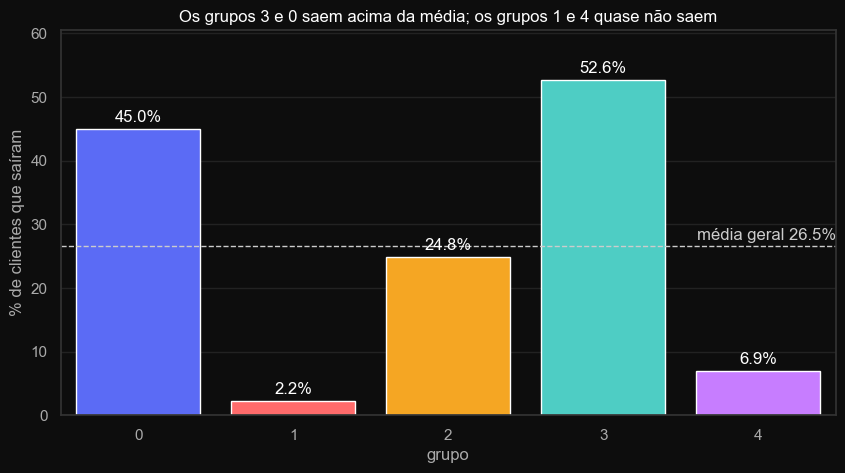

In [28]:
# -----------------------------------------------------------------------------
# 4.6 Taxa de churn por grupo
# -----------------------------------------------------------------------------
# O QUE EU VOU FAZER AQUI
#
# Só agora o Churn volta: groupby(cluster)['Churn'].mean() e a contagem de
# quem saiu em cada grupo. Comparo com a média geral (26,5%) e declaro antes
# o critério de "propenso" e "leal" numa constante.

# --- PARTE 1 — critério declarado ---------------------------------------------
# Propenso = taxa acima da média geral. Leal = taxa abaixo da metade da média.
# Entre os dois = intermediário. Escolhi a metade para "leal" exigir folga.
TAXA_GERAL = gym_clusters['Churn'].mean()
LIMIAR_PROPENSO = TAXA_GERAL
LIMIAR_LEAL = TAXA_GERAL / 2
print(f'Taxa geral: {TAXA_GERAL:.1%} | propenso: acima de {LIMIAR_PROPENSO:.1%} '
    f'| leal: abaixo de {LIMIAR_LEAL:.1%}')

# --- PARTE 2 — taxa e contagem por grupo --------------------------------------
churn_cluster = gym_clusters.groupby('cluster')['Churn'].agg(clientes='size', sairam='sum', taxa='mean')
churn_cluster['% que saiu'] = (churn_cluster['taxa'] * 100).round(1)
churn_cluster['classificação'] = np.select(
    [churn_cluster['taxa'] > LIMIAR_PROPENSO, churn_cluster['taxa'] < LIMIAR_LEAL],
    ['propenso a sair', 'leal'],
    default='intermediário'
)
print('\nSaída por grupo:')
print(churn_cluster.drop(columns='taxa'))

# --- PARTE 3 — gráfico com linha da média geral -------------------------------
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=churn_cluster.reset_index(), x='cluster', y='% que saiu', hue='cluster',
                order=ordem_cluster, palette=COR_CLUSTER, legend=False, saturation=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', color='#ffffff', padding=3)
ax.axhline(TAXA_GERAL * 100, color='#cccccc', linestyle='--', linewidth=1)
ax.text(N_CLUSTERS - 0.5, TAXA_GERAL * 100 + 1, f'média geral {TAXA_GERAL:.1%}',
        color='#cccccc', ha='right')
ax.set_ylim(0, churn_cluster['% que saiu'].max() * 1.15)
plt.title('Os grupos 3 e 0 saem acima da média; os grupos 1 e 4 quase não saem')
plt.xlabel('grupo')
plt.ylabel('% de clientes que saíram')
plt.savefig(f'{PASTA_IMAGENS}/4_6_churn_por_grupo.png')
plt.show()

**Conclusão 4.6 — Os grupos 3 e 0 são propensos a sair, os grupos 1 e 4 são leais, e a taxa de saída vai de 2,2% a 52,6%:**

**O critério.** Declarei antes de olhar os números: propenso a sair é o grupo com taxa acima da média geral de 26,5%, leal é o grupo com taxa abaixo da metade dessa média (13,3%), e o que fica entre os dois é intermediário.

**Os propensos a sair.** O grupo 3, de pouco vínculo, perdeu 583 dos seus 1.108 clientes (52,6%). É o maior grupo e o que mais sai: pela conta com a tabela, ele responde por cerca de 55% de todas as 1.061 saídas da base. O grupo 0, dos clientes que não moram nem trabalham perto, perdeu 245 de 544 (45,0%). Juntos, os dois grupos somam 828 das 1.061 saídas (cerca de 78%, também pela conta com a tabela).

**Os leais.** O grupo 1, do contrato anual, perdeu só 21 de 938 clientes (2,2%), e o grupo 4, dos assíduos, perdeu 53 de 768 (6,9%). Os dois ficam por caminhos diferentes: o grupo 1 está preso a um contrato longo, e o grupo 4 tem contrato curto, mas o hábito de frequentar quase três vezes por semana.

**O intermediário.** O grupo 2, dos indicados, perdeu 159 de 642 clientes (24,8%), perto da média. Ter vindo por indicação de um amigo ajuda, mas sozinho não segura: esse grupo mistura contratos mensais e semestrais (seção 4.5), e a parte mensal provavelmente puxa a taxa para cima (hipótese).

**O que isso diz.** Mesmo com fronteiras fracas entre os grupos (silhueta de 0,128 na 4.3), a taxa de saída muda mais de vinte vezes do grupo mais leal para o mais propenso. Os grupos servem para o negócio: dizem onde concentrar a retenção.

---

# 5. Conclusão geral e recomendações

> **Enunciado (Passo 5):** Tirar conclusões e formular recomendações sobre a estratégia de interação e
> retenção de clientes. Você não precisa entrar em detalhes. Três ou quatro princípios essenciais e exemplos
> da sua implementação na forma de passos de marketing específicos vai funcionar.

**Conclusão geral — Quem sai é o cliente novo, de contrato curto e frequência em queda; dá para prever e agir nos grupos certos:**

1. **Quem sai.** Dos 4.000 clientes, 1.061 saíram (26,5%) (seção 2.1). Saem mais os clientes com pouco tempo de casa, contrato de 1 mês e frequência caindo: saíram 42,3% dos clientes de contrato mensal, contra 2,4% dos de contrato anual (seção 2.3). Os fatores que mais pesam nos dois modelos são o tempo de casa e a frequência no mês (seção 3.5).
2. **Como prevejo.** A regressão logística e a floresta aleatória ficam cerca de 19 pontos acima do chute "ninguém sai" (92,5% e 92,8% de acurácia contra 73,5%), com vantagem nominal da floresta dentro da margem de sorteio. Escolhi a logística por ser mais estável sem a coluna suspeita e mais simples de ler: ela encontra 83,0% dos clientes que saem, com 88,0% de acerto entre os que aponta (seção 3.4).
3. **Os grupos e o que fazer.** Os de pouco vínculo (grupo 3) e os que moram longe (grupo 0) são propensos a sair, com 52,6% e 45,0% de saída. Os de contrato anual (grupo 1) e os assíduos (grupo 4) são leais, com 2,2% e 6,9% (seção 4.6). A academia deve cuidar do primeiro mês, levar o cliente para o contrato longo, agir quando a frequência cai e criar vínculo social, com foco nos grupos 3 e 0.

**Princípios de retenção**

1. **O primeiro mês decide.** Quem saiu tinha em média 0,99 mês de casa, contra 4,71 de quem ficou (seção 2.2). *Passo (sugestão):* boas-vindas com avaliação física na primeira semana e contato do instrutor no fim do primeiro mês.
2. **Contrato longo segura.** *Passo (sugestão):* no mês anterior ao fim do contrato mensal, oferecer o semestral ou o anual com desconto, começando pelos grupos 3 e 0.
3. **A queda de frequência é o alarme.** *Passo (sugestão):* rodar um modelo todo mês e ligar para os clientes com maior probabilidade de saída, com convite para uma aula experimental. Na prática, o alerta deve usar o modelo treinado sem a frequência do mês corrente, porque essa coluna pode medir a própria saída e não estaria disponível antes do mês fechar. Mesmo sem ela, a logística encontra 78,8% dos clientes que saem (seção 3.4). O limiar de 0,3, que encontrou 90,1%, foi testado só no modelo com a coluna e no mesmo conjunto de validação, então esse número é otimista.
4. **Vínculo social ajuda a ficar.** Quem faz aula em grupo sai menos (17,3% contra 33,0%), e quem veio por indicação também (15,8% contra 31,3%) (seção 2.3). *Passo (sugestão):* convidar o grupo 3 para turmas de aula em grupo e dar um benefício para quem trouxer um amigo.

Esses princípios vêm de associação, não de causa. Cada ação deve ser testada antes com um grupo de controle sorteado.

**Os limites**

A frequência no mês corrente pode estar medindo o próprio mês da saída: sem ela os modelos continuam acima da linha de base, mas perdem parte do desempenho (a sensibilidade da logística cai de 83,0% para 78,8%), e a frequência total, quase gêmea dela (r = 0,95), continuou no modelo (seções 2.4 e 3.4). As colunas gêmeas distorcem os coeficientes da logística: a frequência total aparece com sinal invertido (seção 3.5). Os resultados vêm de uma única divisão com 212 clientes que saíram na validação, e diferenças pequenas entre modelos ficam dentro da margem do sorteio; o limiar de 0,3 foi escolhido e medido nessa mesma validação (seção 3.4). A base é um retrato de um mês só, sem histórico. Os 5 grupos vêm do enunciado, não dos dados: o dendrograma sugere 4, a silhueta é fraca, de 0,128, e o K-Means usa um ponto de partida fixo para dar os mesmos grupos em qualquer versão do sklearn (seções 4.2 e 4.3). O enunciado não informa a codificação de `gender` nem o custo de cada erro do modelo.

**Outros padrões que vi**

O telefone não muda nada: cerca de 90% em todos os grupos e correlação zero com a saída (seções 2.4 e 4.5). A indicação de amigo sozinha não basta: o grupo 2, com 100% de indicados, ficou perto da média de saída (seção 4.6). E existem dois caminhos de fidelidade, o contrato longo do grupo 1 e o hábito de frequentar do grupo 4, o que sugere que a academia pode reter tanto pela oferta de contrato quanto pela rotina de treino (hipótese).